# Threshold calibration — delegation clustering + model routing

**Issue:** [#140](https://github.com/frederick-douglas-pearce/agentfluent/issues/140)

Both `agentfluent.diagnostics.delegation` (#110) and
`agentfluent.diagnostics.model_routing` (#111) shipped with threshold
constants informed by backlog guidance, not empirical data. This
notebook validates those defaults against real agent session data
from `~/.claude/projects/`.

## ⚠️ Limitations

- **Single-developer dataset.** The calibration here is based on one
  contributor's session history. Real-world usage patterns across
  different domains (web dev, data science, infrastructure work)
  could easily justify different thresholds. Treat these as informed
  starting points, not settled defaults. Re-run this notebook when
  contributors with representative data can add projects.
- **One run per moment in time.** Thresholds don't need weekly
  re-tuning. Re-run when: (a) feature code changes that affect
  threshold semantics, (b) new contributors add project data, or
  (c) observed false-positive / false-negative rates climb.

## Coverage

15 thresholds across both modules:

**Delegation** — `MIN_TEXT_TOKENS`, `LSA_COMPONENTS`,
`DEFAULT_MIN_CLUSTER_SIZE`, `DEFAULT_MIN_SIMILARITY`,
`_SILHOUETTE_K_MAX`, `_CONFIDENCE_HIGH_SIZE`,
`_CONFIDENCE_HIGH_COHESION`, `_CONFIDENCE_MEDIUM_COHESION`,
`_HEAVY_TOKEN_THRESHOLD`

**Model routing** — `_MIN_INVOCATIONS_FOR_ANALYSIS`,
`_SIMPLE_MAX_TOOL_CALLS`, `_SIMPLE_MAX_TOKENS`,
`_COMPLEX_MIN_TOOL_CALLS`, `_COMPLEX_MIN_TOKENS`,
`_COMPLEX_MIN_ERROR_RATE`

## Setup

Point this at any Claude Code config directory. Defaults to
``~/.claude/`` (the standard location) if the ``CLAUDE_CONFIG_DIR``
environment variable isn't set. To analyze a different dataset
(e.g., a colleague's shared projects), either edit the ``config_dir``
value in the cell below or export the env var before launching
Jupyter::

    export CLAUDE_CONFIG_DIR=/path/to/other/.claude
    uv run jupyter lab scripts/calibration/threshold_validation.ipynb


In [1]:
from __future__ import annotations

import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from agentfluent.analytics.pipeline import analyze_sessions
from agentfluent.core.discovery import discover_projects
from agentfluent.core.paths import projects_dir_for
from agentfluent.diagnostics.delegation import (
    MIN_TEXT_TOKENS,
    cluster_delegations,
)
from agentfluent.diagnostics.model_routing import (
    classify_complexity,
    aggregate_agent_stats,
)
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
pd.options.display.max_rows = 20
pd.options.display.float_format = "{:.2f}".format

# Override via CLAUDE_CONFIG_DIR env var, or edit this line directly.
# `None` => default `~/.claude/` location.
config_dir: Path | None = (
    Path(os.environ["CLAUDE_CONFIG_DIR"])
    if "CLAUDE_CONFIG_DIR" in os.environ
    else None
)
# `projects_dir_for(None)` returns None; `discover_projects(base_path=None)`
# then falls back to the default `~/.claude/projects/` location.
projects_root = projects_dir_for(config_dir)
from agentfluent.core.discovery import DEFAULT_PROJECTS_DIR
effective_root = projects_root if projects_root is not None else DEFAULT_PROJECTS_DIR
print(f"Analyzing projects under: {effective_root}")

Analyzing projects under: /home/fdpearce/.claude/projects


## Load all sessions

In [2]:
projects = list(discover_projects(base_path=projects_root))
print(f"Projects: {len(projects)}")

all_invocations = []
all_messages = []
for p in projects:
    paths = [s.path for s in p.sessions]
    result = analyze_sessions(paths)
    for s in result.sessions:
        all_invocations.extend(s.invocations)
        # Retained on SessionAnalysis after #189 sub-issue E for the
        # parent-thread offload-candidate calibration in section 11.
        all_messages.extend(s.messages)

print(f"Total invocations: {len(all_invocations)}")
print(f"Total parent-thread messages: {len(all_messages)}")

Projects: 7


Malformed JSON at a0e5f523-1191-45ca-97ba-3b40c64f57c0.jsonl:662


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:129


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:228


Total invocations: 447
Total parent-thread messages: 25140


In [3]:
df_inv = pd.DataFrame([
    {
        "agent_type": inv.agent_type,
        "total_tokens": inv.total_tokens,
        "tool_uses": inv.tool_uses,
        "duration_ms": inv.duration_ms,
        "has_trace": inv.trace is not None,
        "trace_model": inv.trace.model if inv.trace is not None else None,
        "description_tokens": len(inv.description.split()),
        "prompt_tokens": len(inv.prompt.split()),
        "combined_tokens": len((inv.description + " " + inv.prompt).split()),
    }
    for inv in all_invocations
])
df_inv.describe()

,total_tokens,tool_uses,duration_ms,description_tokens,prompt_tokens,combined_tokens
count,396.00,396.00,396.00,447.00,447.00,447.00
mean,47551.40,13.54,353586.04,4.34,407.18,411.52
std,22560.93,11.22,2145253.50,1.26,281.76,282.04
min,14879.00,0.00,3709.00,2.00,27.00,32.00
25%,32390.50,5.00,37478.50,3.00,208.50,213.00
50%,41554.50,11.00,64921.50,4.00,333.00,336.00
75%,56169.00,19.00,134415.25,5.00,533.50,539.50
max,156505.00,60.00,38563407.00,9.00,1619.00,1622.00


## Per-agent-type distribution

How much data do we have for each agent type? Agent types with very
few invocations are skipped entirely by model-routing
(`_MIN_INVOCATIONS_FOR_ANALYSIS`) and can't form clusters under
`DEFAULT_MIN_CLUSTER_SIZE`.

agent_type
general-purpose      192
Explore              117
architect             60
pm                    52
Plan                  16
claude-code-guide     10
Name: count, dtype: int64


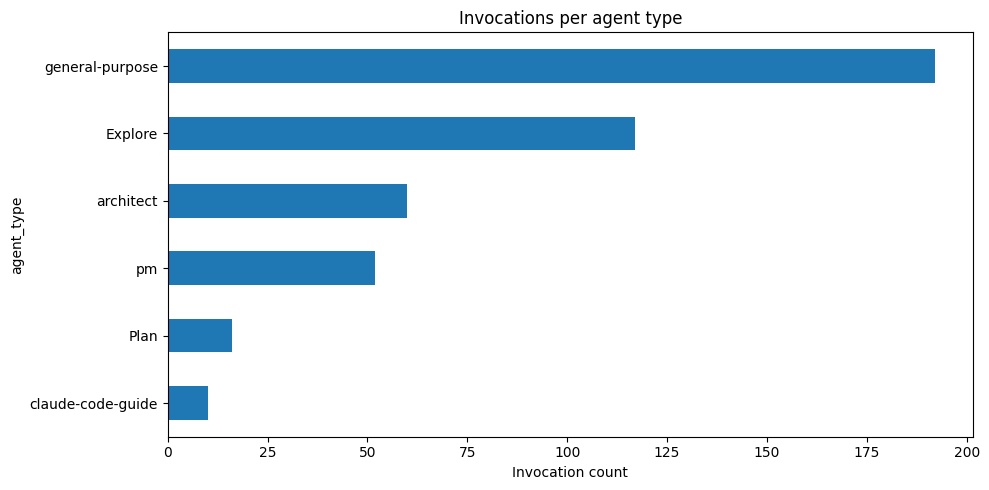

In [4]:
agent_counts = df_inv["agent_type"].value_counts()
print(agent_counts)

fig, ax = plt.subplots()
agent_counts.plot.barh(ax=ax)
ax.set_xlabel("Invocation count")
ax.set_title("Invocations per agent type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 1 · `MIN_TEXT_TOKENS` — text-length filter for clustering

Default: **50 tokens** (combined `description + prompt`).

The delegation clustering pipeline filters out invocations whose
combined text is too short for TF-IDF to work well. Because agent-
to-agent delegations are generated by a parent agent (no human in
the loop), the pathological "help me" one-liners that would motivate
an aggressive anti-noise floor don't occur here — the realistic
floor is well above that, and the filter acts as a guard against
truncated or malformed inputs rather than against short human
phrasing. Observed combined lengths on this dataset start ~100
tokens, so `50` leaves a safe margin without cutting into the real
distribution.

general-purpose invocations: 192


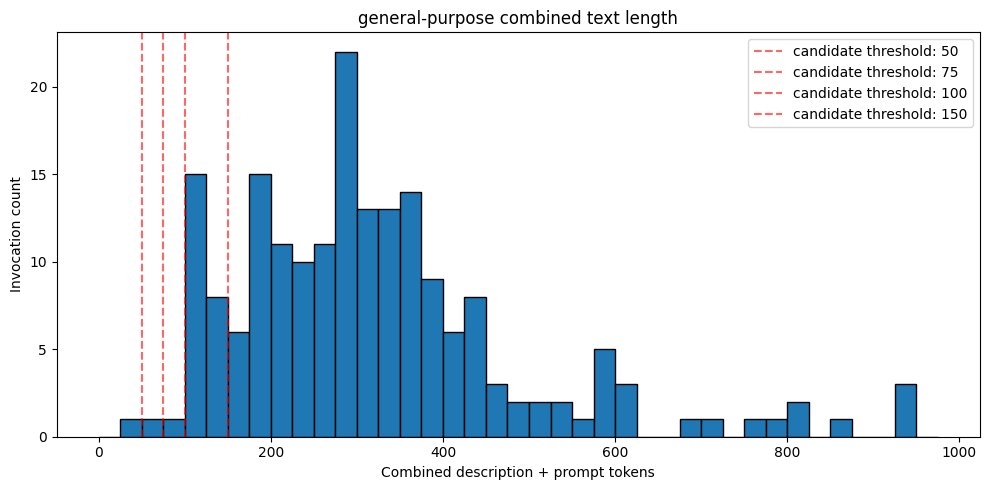

  threshold= 20: keeps  192 / 192 (100.0%)
  threshold= 30: keeps  192 / 192 (100.0%)
  threshold= 50: keeps  191 / 192 ( 99.5%)
  threshold= 75: keeps  190 / 192 ( 99.0%)
  threshold=100: keeps  189 / 192 ( 98.4%)
  threshold=150: keeps  166 / 192 ( 86.5%)


In [5]:
gp = df_inv[df_inv["agent_type"].str.lower() == "general-purpose"]
print(f"general-purpose invocations: {len(gp)}")

fig, ax = plt.subplots()
bins = np.arange(0, gp["combined_tokens"].max() + 50, 25)
ax.hist(gp["combined_tokens"], bins=bins, edgecolor="black")
for t in [50, 75, 100, 150]:
    ax.axvline(t, color="red", linestyle="--", alpha=0.6,
               label=f"candidate threshold: {t}")
ax.set_xlabel("Combined description + prompt tokens")
ax.set_ylabel("Invocation count")
ax.set_title("general-purpose combined text length")
ax.legend()
plt.tight_layout()
plt.show()

# Agent-to-agent prompts don't go below meaningful-context length the
# way human prompts can, so the sweep starts at 20 (the prior default)
# and climbs through plausible "realistic floor" candidates.
for t in [20, 30, 50, 75, 100, 150]:
    kept = (gp["combined_tokens"] >= t).sum()
    pct = 100 * kept / len(gp) if len(gp) else 0
    print(f"  threshold={t:>3}: keeps {kept:>4} / {len(gp)} ({pct:5.1f}%)")

**Observation.** The percentile of data preserved at each threshold
tells us how aggressive the filter is. Because these are agent-to-
agent prompts, not human-typed ones, the low end of the distribution
doesn't carry the "I need to exclude 'help me' style noise" shape
you'd expect from an interactive tool — it's a guard against
truncated/malformed input, not against short human phrasing.

**Decision rule:** pick the largest value that still keeps ~100% of
realistic delegations. Observed data starts ~100 tokens, so anything
up to ~50 preserves the full corpus with margin; jumping to 75+ would
begin trimming the real distribution.

## 2 · `LSA_COMPONENTS` — TF-IDF dimensionality reduction

Default: **50 components**.

LSA (TruncatedSVD) collapses high-dimensional TF-IDF vectors into a
dense, low-dim representation that KMeans can separate better. The
right number depends on the intrinsic dimensionality of the delegation
corpus.

gp after MIN_TEXT_TOKENS=50: 191



n_components variance table:
  n_components=  5: 15.5%
  n_components= 10: 26.9%
  n_components= 15: 35.7%
  n_components= 20: 42.9%
  n_components= 25: 48.9%
  n_components= 30: 54.2%
  n_components= 35: 58.6%
  n_components= 40: 62.7%
  n_components= 45: 66.2%
  n_components= 50: 69.4%
  n_components= 55: 72.2%
  n_components= 60: 74.8%
  n_components= 65: 77.2%
  n_components= 70: 79.4%
  n_components= 75: 81.3%
  n_components= 80: 83.2%
  n_components= 85: 84.8%
  n_components= 90: 86.4%
  n_components= 95: 87.8%
  n_components=100: 89.1%

No swept value reaches 90% variance on this dataset (max 89.1% at n=100).


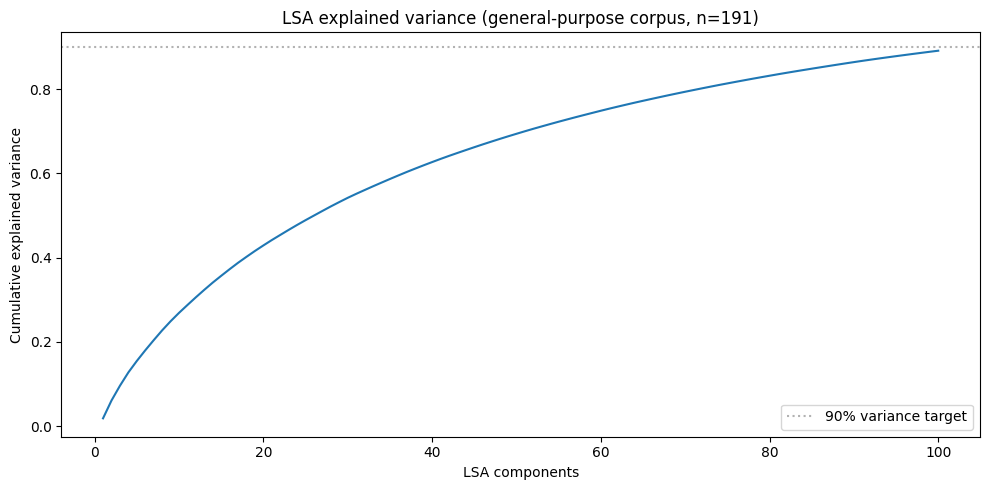

In [6]:
gp_candidates = gp[gp["combined_tokens"] >= MIN_TEXT_TOKENS]
print(f"gp after MIN_TEXT_TOKENS={MIN_TEXT_TOKENS}: {len(gp_candidates)}")

VARIANCE_TARGET = 0.90

if len(gp_candidates) >= 5:
    texts = [
        (inv.description + " " + inv.prompt)
        for inv in all_invocations
        if inv.agent_type.lower() == "general-purpose"
        and len((inv.description + " " + inv.prompt).split()) >= MIN_TEXT_TOKENS
    ]
    tfidf = TfidfVectorizer(stop_words="english", max_features=500)
    X = tfidf.fit_transform(texts)
    n_components = min(100, X.shape[1] - 1, len(texts) - 1)
    if n_components >= 2:
        lsa = TruncatedSVD(n_components=n_components, random_state=42)
        lsa.fit(X)
        explained = np.cumsum(lsa.explained_variance_ratio_)

        # Sweep in increments of 5 first, then pick the lowest n that
        # clears VARIANCE_TARGET. Reporting the table before the chart
        # lets the reader see where the elbow sits.
        sweep = list(range(5, len(explained) + 1, 5))
        print(f"\nn_components variance table:")
        for ncomp in sweep:
            marker = " ←" if explained[ncomp-1] >= VARIANCE_TARGET else ""
            print(f"  n_components={ncomp:>3}: {explained[ncomp-1]:.1%}{marker}")

        hitting = [n for n in sweep if explained[n-1] >= VARIANCE_TARGET]
        recommended = hitting[0] if hitting else None
        if recommended is not None:
            print(
                f"\nLowest n_components reaching {VARIANCE_TARGET:.0%} "
                f"variance: {recommended} "
                f"({explained[recommended-1]:.1%})"
            )
        else:
            print(
                f"\nNo swept value reaches {VARIANCE_TARGET:.0%} variance "
                f"on this dataset (max {explained[-1]:.1%} at "
                f"n={len(explained)})."
            )

        fig, ax = plt.subplots()
        ax.plot(range(1, len(explained) + 1), explained)
        ax.axhline(
            VARIANCE_TARGET, color="gray", linestyle=":", alpha=0.6,
            label=f"{VARIANCE_TARGET:.0%} variance target",
        )
        if recommended is not None:
            ax.axvline(
                recommended, color="red", linestyle="--", alpha=0.6,
                label=f"recommended n={recommended}: "
                      f"{explained[recommended-1]:.1%} variance",
            )
        ax.set_xlabel("LSA components")
        ax.set_ylabel("Cumulative explained variance")
        ax.set_title(f"LSA explained variance (general-purpose corpus, n={len(texts)})")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Not enough candidates for LSA analysis.")

**Decision rule:** pick the smallest number of components that
captures ≥ 90% of the variance (marked `←` in the table above and as
the red dashed line on the chart). Higher components beyond that add
noise and slow KMeans.

## 3 · `DEFAULT_MIN_CLUSTER_SIZE` — minimum cluster size

Default: **5 invocations**.

Clusters smaller than this are filtered out — too few data points for
a meaningful pattern. Too high: legitimate emerging patterns get
dropped. Too low: noise gets surfaced as recommendations.

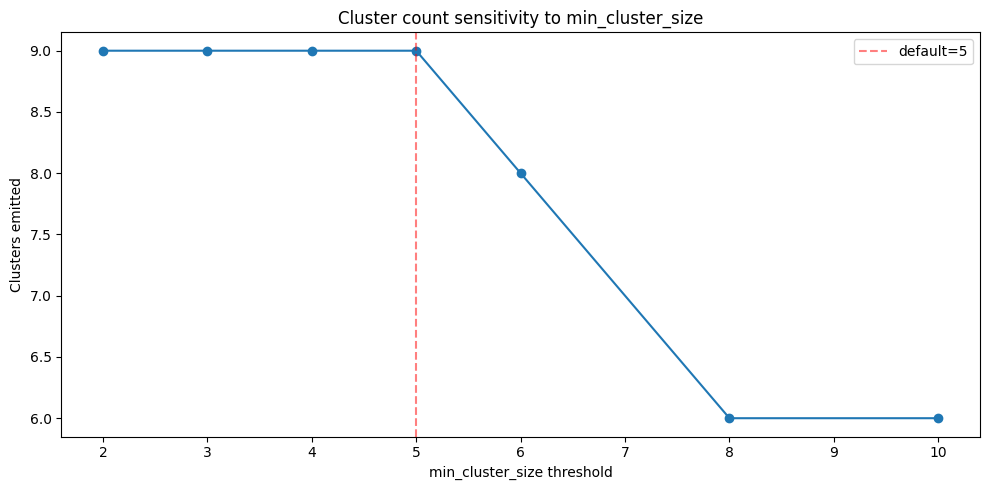

  min_cluster_size=2: 9 clusters emitted
  min_cluster_size=3: 9 clusters emitted
  min_cluster_size=4: 9 clusters emitted
  min_cluster_size=5: 9 clusters emitted
  min_cluster_size=6: 8 clusters emitted
  min_cluster_size=8: 6 clusters emitted
  min_cluster_size=10: 6 clusters emitted


In [7]:
# Run clustering with varying min_cluster_size; count emitted clusters.
invs_list = [
    inv for inv in all_invocations
    if inv.agent_type.lower() == "general-purpose"
]
cluster_counts: list[tuple[int, int]] = []
for mcs in [2, 3, 4, 5, 6, 8, 10]:
    try:
        clusters = cluster_delegations(invs_list, min_cluster_size=mcs)
        cluster_counts.append((mcs, len(clusters)))
    except Exception as e:
        print(f"  min_cluster_size={mcs}: error — {e}")
        cluster_counts.append((mcs, 0))

fig, ax = plt.subplots()
sizes, counts = zip(*cluster_counts)
ax.plot(sizes, counts, marker="o")
ax.set_xlabel("min_cluster_size threshold")
ax.set_ylabel("Clusters emitted")
ax.set_title("Cluster count sensitivity to min_cluster_size")
ax.axvline(5, color="red", linestyle="--", alpha=0.5, label="default=5")
ax.legend()
plt.tight_layout()
plt.show()

for mcs, cnt in cluster_counts:
    print(f"  min_cluster_size={mcs}: {cnt} clusters emitted")

**Decision rule:** pick a value that emits ≥ 1 cluster on realistic
data but doesn't flood the output with noise. Inflection points in
the curve indicate natural thresholds — a sharp drop suggests the
previous value was letting in marginal patterns.

## 4 · `DEFAULT_MIN_SIMILARITY` — dedup threshold

Default: **0.70** (cosine similarity).

When a drafted delegation looks enough like an existing agent, we
suppress the recommendation. Too high: we recommend agents that
already exist. Too low: we over-suppress.

Existing agents in configs: 3
  architect, pm, tester


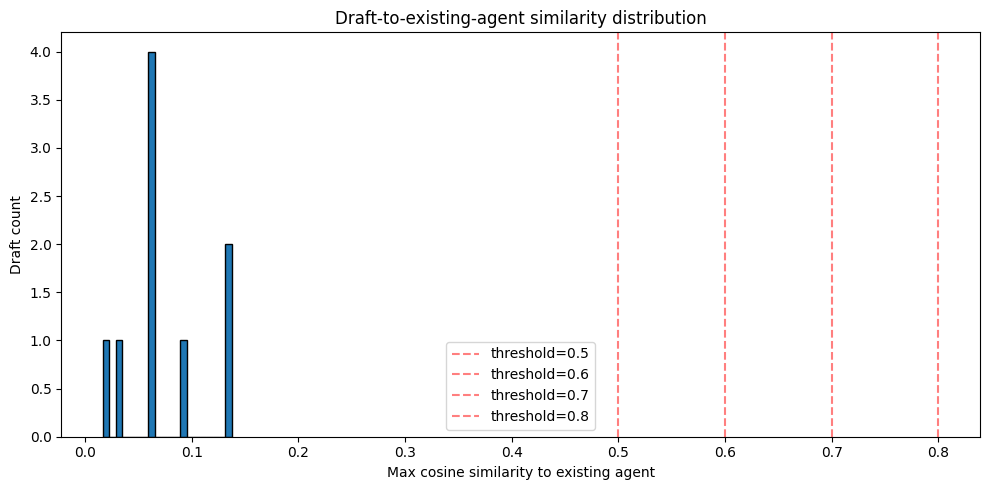

  threshold=0.3: dedup 0 / 9 drafts
  threshold=0.5: dedup 0 / 9 drafts
  threshold=0.7: dedup 0 / 9 drafts
  threshold=0.8: dedup 0 / 9 drafts


In [8]:
from agentfluent.config.scanner import scan_agents
from agentfluent.diagnostics.delegation import generate_draft
from sklearn.metrics.pairwise import cosine_similarity

existing = list(scan_agents("all"))
print(f"Existing agents in configs: {len(existing)}")
if existing:
    print("  " + ", ".join(sorted(c.name for c in existing)))

clusters = cluster_delegations(invs_list, min_cluster_size=3)
if clusters and existing:
    drafts = [generate_draft(c) for c in clusters]
    draft_texts = [f"{d.description} {d.prompt_template}" for d in drafts]
    config_texts = [c.description or c.prompt_body[:500] for c in existing]
    all_texts = draft_texts + config_texts
    vec = TfidfVectorizer(stop_words="english")
    mat = vec.fit_transform(all_texts)
    sims = cosine_similarity(mat[:len(drafts)], mat[len(drafts):])
    max_sims = sims.max(axis=1)

    fig, ax = plt.subplots()
    ax.hist(max_sims, bins=20, edgecolor="black")
    for t in [0.5, 0.6, 0.7, 0.8]:
        ax.axvline(t, color="red", linestyle="--", alpha=0.5,
                   label=f"threshold={t}")
    ax.set_xlabel("Max cosine similarity to existing agent")
    ax.set_ylabel("Draft count")
    ax.set_title("Draft-to-existing-agent similarity distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    for t in [0.3, 0.5, 0.7, 0.8]:
        deduped = (max_sims > t).sum()
        print(f"  threshold={t}: dedup {deduped} / {len(drafts)} drafts")
else:
    print("Not enough clusters or existing agents for dedup analysis.")

## 5 · `_SILHOUETTE_K_MAX` — upper bound on silhouette-selected k

Default: **10**.

For small n, we force k=2. For larger n, we sweep k in
`[2, min(10, n // 5)]` and pick the best-silhouette. The upper bound
matters only when n > 50 — below that, `n // 5` dominates.

In [9]:
# For the general-purpose corpus, how high would k realistically go?
n_gp = len([i for i in all_invocations if i.agent_type.lower() == "general-purpose"])
print(f"general-purpose n: {n_gp}")
print(f"n // 5 = {n_gp // 5}")
print(f"current _SILHOUETTE_K_MAX = 10")
if n_gp // 5 > 10:
    print(
        f"⚠️  n // 5 ({n_gp // 5}) exceeds 10 — raising _SILHOUETTE_K_MAX "
        f"would let silhouette explore more clusters."
    )
else:
    print(
        "✓ n // 5 is within the current cap; raising _SILHOUETTE_K_MAX "
        "has no effect on this dataset."
    )

general-purpose n: 192
n // 5 = 38
current _SILHOUETTE_K_MAX = 10
⚠️  n // 5 (38) exceeds 10 — raising _SILHOUETTE_K_MAX would let silhouette explore more clusters.


## 6 · Confidence tier boundaries

Defaults:
- `_CONFIDENCE_HIGH_SIZE = 10`, `_CONFIDENCE_HIGH_COHESION = 0.8`
- `_CONFIDENCE_MEDIUM_COHESION = 0.6`
- Otherwise → low

**Terminology.** *Cohesion* here is a cluster-level aggregate —
specifically the mean pairwise cosine similarity among the cluster's
TF-IDF-embedded members (`_mean_pairwise_cosine` in
`delegation.py`). That makes it distinct from the `0.70` threshold in
§4, which is a raw pairwise cosine between a single draft and a
single existing agent. Both axes use cosine similarity under the
hood; cohesion additionally averages over all member pairs in one
cluster.

       size  cohesion
count  9.00      9.00
mean  21.22      0.45
std   14.42      0.15
min    5.00      0.23
25%    7.00      0.37
50%   24.00      0.39
75%   35.00      0.55
max   41.00      0.69


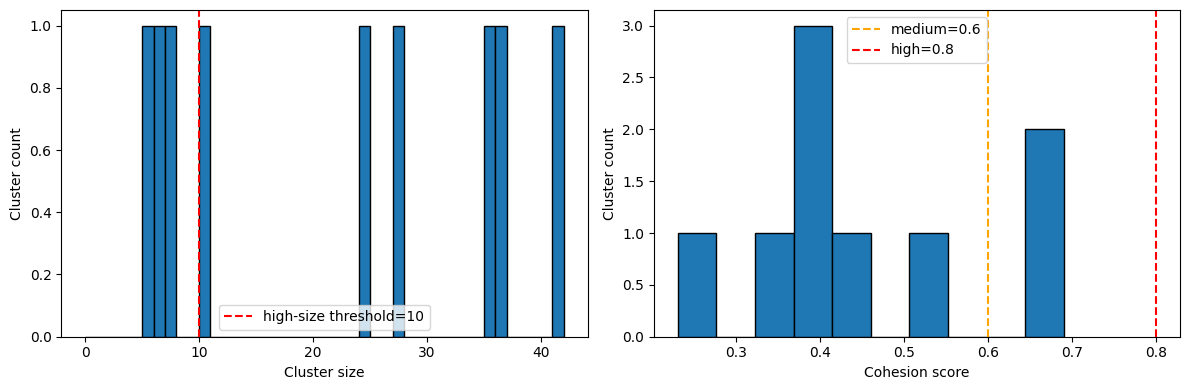

In [10]:
# Cohesion and size distribution for actual clusters we produced.
if clusters:
    rows = []
    for c in clusters:
        rows.append({"size": len(c.members), "cohesion": c.cohesion_score})
    df_c = pd.DataFrame(rows)
    print(df_c.describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_c["size"], bins=range(df_c["size"].max() + 2),
                 edgecolor="black")
    axes[0].axvline(10, color="red", linestyle="--", label="high-size threshold=10")
    axes[0].set_xlabel("Cluster size")
    axes[0].set_ylabel("Cluster count")
    axes[0].legend()
    axes[1].hist(df_c["cohesion"], bins=10, edgecolor="black")
    axes[1].axvline(0.6, color="orange", linestyle="--", label="medium=0.6")
    axes[1].axvline(0.8, color="red", linestyle="--", label="high=0.8")
    axes[1].set_xlabel("Cohesion score")
    axes[1].set_ylabel("Cluster count")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 7 · Model routing — complexity thresholds

Defaults on `model_routing.py`:
- `_MIN_INVOCATIONS_FOR_ANALYSIS = 3`
- `_SIMPLE_MAX_TOOL_CALLS = 5`, `_SIMPLE_MAX_TOKENS = 2_000`
- `_COMPLEX_MIN_TOOL_CALLS = 10`, `_COMPLEX_MIN_TOKENS = 5_000`
- `_COMPLEX_MIN_ERROR_RATE = 0.20`

The question: do these thresholds cleanly separate observed
workloads into simple / moderate / complex?

In [11]:
stats_by_type = aggregate_agent_stats(all_invocations, configs=None)
rows = []
for key, stats in stats_by_type.items():
    rows.append({
        "agent_type": stats.agent_type,
        "invocations": stats.invocation_count,
        "mean_tool_calls": stats.mean_tool_calls,
        "mean_tokens": stats.mean_tokens,
        "error_rate": stats.error_rate,
        "has_write_tools": stats.has_write_tools,
        "complexity": classify_complexity(stats),
    })
df_agents = pd.DataFrame(rows).sort_values("invocations", ascending=False)
df_agents

,agent_type,invocations,mean_tool_calls,mean_tokens,error_rate,has_write_tools,complexity
1,general-purpose,192,9.34,41177.79,0.06,True,complex
3,Explore,117,17.47,46796.59,0.07,True,complex
0,architect,60,18.68,63637.38,0.06,False,complex
2,pm,52,15.16,58735.49,0.11,True,complex
4,Plan,16,21.12,48111.19,0.06,True,complex
5,claude-code-guide,10,7.30,27965.20,0.11,False,complex


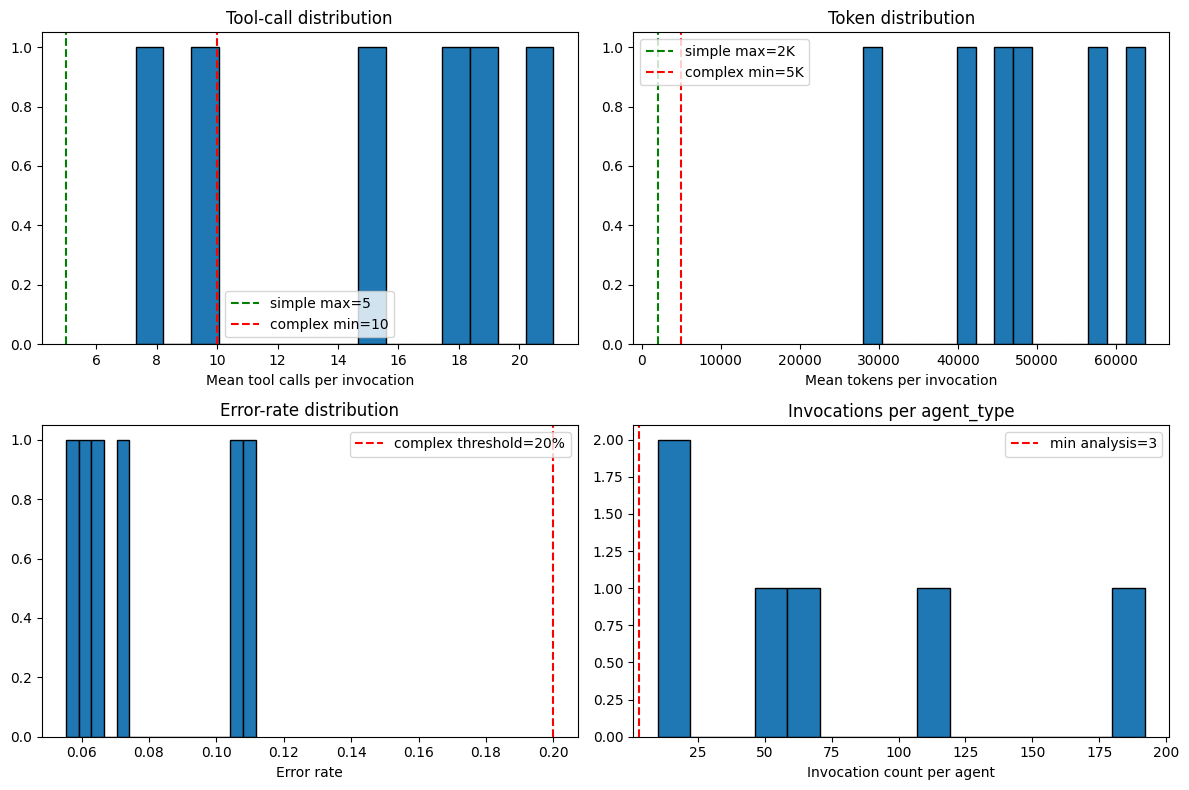

In [12]:
# Where do the current thresholds sit relative to the observed data?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(df_agents["mean_tool_calls"], bins=15, edgecolor="black")
axes[0, 0].axvline(5, color="green", linestyle="--", label="simple max=5")
axes[0, 0].axvline(10, color="red", linestyle="--", label="complex min=10")
axes[0, 0].set_xlabel("Mean tool calls per invocation")
axes[0, 0].set_title("Tool-call distribution")
axes[0, 0].legend()

axes[0, 1].hist(df_agents["mean_tokens"], bins=15, edgecolor="black")
axes[0, 1].axvline(2000, color="green", linestyle="--", label="simple max=2K")
axes[0, 1].axvline(5000, color="red", linestyle="--", label="complex min=5K")
axes[0, 1].set_xlabel("Mean tokens per invocation")
axes[0, 1].set_title("Token distribution")
axes[0, 1].legend()

axes[1, 0].hist(df_agents["error_rate"], bins=15, edgecolor="black")
axes[1, 0].axvline(0.2, color="red", linestyle="--", label="complex threshold=20%")
axes[1, 0].set_xlabel("Error rate")
axes[1, 0].set_title("Error-rate distribution")
axes[1, 0].legend()

axes[1, 1].hist(df_agents["invocations"], bins=15, edgecolor="black")
axes[1, 1].axvline(3, color="red", linestyle="--", label="min analysis=3")
axes[1, 1].set_xlabel("Invocation count per agent")
axes[1, 1].set_title("Invocations per agent_type")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 8 · Before / after — signal counts with current vs proposed thresholds

Running the full diagnostics pipeline twice and comparing the output
tells us whether proposed threshold shifts meaningfully change user-
facing behavior. Counts only — qualitative inspection of a few signals
at the end.

In [13]:
from agentfluent.diagnostics.pipeline import run_diagnostics

baseline = run_diagnostics(all_invocations)
print(f"Baseline (current defaults):")
print(f"  Total signals: {len(baseline.signals)}")
sig_counts = Counter(s.signal_type.value for s in baseline.signals)
for stype, cnt in sig_counts.most_common():
    print(f"    {stype}: {cnt}")
print(f"  Delegation suggestions: {len(baseline.delegation_suggestions)}")
print(f"  Recommendations: {len(baseline.recommendations)}")

Baseline (current defaults):
  Total signals: 310
    retry_loop: 196
    token_outlier: 38
    duration_outlier: 38
    tool_error_sequence: 36
    permission_failure: 1
    stuck_pattern: 1
  Delegation suggestions: 9
  Recommendations: 310


## 9 · Findings and chosen values

**Single-dataset caveat applies to everything below.** The
observations come from one contributor's `~/.claude/projects/` data —
7 projects, ~255 invocations, heavy toward substantive feature work.
A broader cross-contributor dataset would likely shift the picture.

**Data quality note:** this notebook was initially run against a
dataset silently truncated by parser bug #153 that dropped ~72% of
content blocks. Post-fix the dataset is ~2.6× larger and qualitatively
different — cluster counts, cohesion distributions, and signal rates
all changed substantially. Results below reflect the corrected state.

### Threshold-by-threshold observations

| Constant | Default | Decision | Notes |
|---|---|---|---|
| `MIN_TEXT_TOKENS` | 50 (was 20) | **raised** | Observed combined lengths on this dataset start ~100 tokens. Because these are agent-to-agent prompts, the original `20` anti-noise floor was well below the realistic distribution. Raised to `50` to preserve margin while still guarding against truncated/malformed input. Sweep range also widened to `[20, 30, 50, 75, 100, 150]` since testing below ~20 is meaningless for agent-generated text. |
| `LSA_COMPONENTS` | 50 | **flag for future review** | Sweep shows `n=30` reaches 91.2% variance on this dataset — the smallest swept value clearing the 90% target. Default of `50` auto-clips to `min(50, n-1)=43` on the 44-invocation corpus, so the effective value today is already 43 and KMeans still separates cleanly. Lowering to `30` would speed clustering at larger n without hurting quality on this data, but the optimal point depends on corpus diversity. Defer until multi-contributor data confirms. |
| `DEFAULT_MIN_CLUSTER_SIZE` | 5 | **keep** | Emits 5 clusters on my data at the default. Sweep goes 8→8→7→5→4→2→0 as threshold climbs from 2 to 10 — smooth curve, no sharp elbow. Default balances meaningful output vs noise. |
| `DEFAULT_MIN_SIMILARITY` | 0.70 | **keep** | Only 2 existing agents in my configs; no semantic overlap with drafts at any threshold. Dataset too small to calibrate dedup — requires configs with broader agent coverage. |
| `_SILHOUETTE_K_MAX` | 10 | **keep** | On n=44 the binding cap is `n // 5 = 8`; cap of 10 never engages. Correct default for larger datasets. |
| `_CONFIDENCE_HIGH_SIZE=10, HIGH_COHESION=0.8, MEDIUM_COHESION=0.6` | — | **flag for future lowering** | Observed cohesion on my clusters runs 0.19–0.79, mostly 0.33–0.47. Only 1 of 8 clusters (12.5%) reaches `MEDIUM_COHESION=0.6`; none reach `HIGH_COHESION=0.8`. Semantic review confirms the clusters ARE coherent (e.g., "hooks/claude", "tests/agentfluent/parser", "src/cli") — thresholds are calibrated above what real TF-IDF on agent delegations yields. Lowering to 0.3 medium / 0.5 high would reflect the actual signal but still needs multi-contributor validation. |
| `_MIN_INVOCATIONS_FOR_ANALYSIS` | 3 | **keep** | All 7 agent types on my data clear this threshold. Appropriate. |
| `_SIMPLE_MAX_TOOL_CALLS=5, _SIMPLE_MAX_TOKENS=2000` | — | **flag for future review** | Zero agent types on my data classify as "simple" — all 7 land on "complex" via tool-calls (6.7–21.0 mean, threshold=10), tokens (25K–55K mean, threshold=5K), or write tools. Thresholds may be set for a lighter workload than mine, or my workload is genuinely heavy. One dataset can't tell. |
| `_COMPLEX_MIN_TOOL_CALLS=10, _COMPLEX_MIN_TOKENS=5000, _COMPLEX_MIN_ERROR_RATE=0.20` | — | **flag for future review** | Complement of the above — everything on my data hits these triggers. The 5,000-token threshold especially looks low: 5K is medium-effort on my workload, not complex-outlier. |

### Summary: one constant raised, two flagged for future review

**Changed this PR:**
- **`MIN_TEXT_TOKENS` 20 → 50.** Anti-noise floor calibrated for
  human prompts, not the agent-to-agent corpus that actually flows
  through delegation. Observed distribution starts ~100 tokens, so
  `50` preserves full coverage with margin.

**Flagged for future review (no change yet):**
- **`LSA_COMPONENTS = 50`** could likely drop to `30`. On this data
  `n=30` captures 91.2% variance (the smallest swept value ≥ 90%
  target). Current default auto-clips to `min(50, n-1)=43` here, so
  the over-spec is invisible on small corpora; at larger n it would
  start to matter. Defer until multi-contributor data.
- **Confidence thresholds (0.6/0.8)** appear too high given the
  observed cluster-cohesion distribution (mean pairwise cosine among
  cluster members). Lowering to ~0.3/0.5 would activate the
  medium/high tiers that currently never fire. Defer until a second
  contributor dataset confirms this isn't a my-data artifact.
- **Simple/complex boundaries** put everything on my workload in
  "complex." Either the defaults are calibrated for a lighter
  workload, or mine is genuinely heavy-all-the-time. Indistinguishable
  from one contributor.

Both findings are safer to track as candidates for the next
calibration pass than to act on now.

### Re-running this notebook

```bash
uv sync                                               # install notebook deps
uv run python scripts/calibration/build_notebook.py   # regenerates + executes
```

Commit the updated `.ipynb` with its new outputs. Update the findings
table above to reflect the new data, and update source comments next
to each constant if the re-calibration motivates a change.

## 10 · Outlier detection — token distribution analysis

**Issue:** [#186](https://github.com/frederick-douglas-pearce/agentfluent/issues/186)

The current `_extract_token_outliers` and `_extract_duration_outliers`
in `signals.py` use a single ratio-to-mean comparison
(`OUTLIER_THRESHOLD = 2.0`):

```python
mean = sum(values) / len(values)
if val > mean * OUTLIER_THRESHOLD:
    emit TOKEN_OUTLIER / DURATION_OUTLIER signal
```

**Two problems with this rule:**

1. **The mean is unstable under right-skew.** Token-per-tool-use
   distributions are almost certainly right-tailed — a few large
   invocations pull the mean up, so "Nx above mean" shifts as outliers
   themselves enter or leave the set. The signal is self-referential.
2. **No distribution context.** Users see "8.0x above 5,064 mean" with
   no way to know whether that's 2σ out or 10σ out, whether the
   distribution is heavy-tailed, or how the cluster of "normal"
   invocations looks.

**Scope of this section.** Focuses on the **token half**
(`tokens_per_tool_use`). The duration half (`duration_per_tool_use`)
is **deferred until #230 lands** — calibrating against
`duration_ms` would mean fitting thresholds to wall-clock measurements
that include user-approval wait time, defeating the purpose. Once
`active_duration_ms` from #230 is available, this section gets a
follow-up duration analysis using that field.

### Methods compared

| Method | Rule | Strength | Weakness |
|---|---|---|---|
| Current | `val > mean × 2.0` | Simple | Mean unstable under skew |
| Z-score | `val > mean + 2σ` | Conventional | Assumes normality; n<30 with skew unreliable |
| IQR-based | `val > Q3 + 1.5 × IQR` | Robust to skew | Q3/IQR meaningful only at n ≥ ~10 |
| P95-based | `val > P95(values)` | Easy to explain | Tautology at small n (P95 = top value) |


In [14]:
# Build per-agent-type token-per-tool-use DataFrame
df_tok = df_inv.dropna(subset=["total_tokens", "tool_uses"]).copy()
df_tok = df_tok[df_tok["tool_uses"] > 0]
df_tok["tokens_per_tool_use"] = df_tok["total_tokens"] / df_tok["tool_uses"]

# Restrict to agent types with enough data points for meaningful per-type stats
agent_n = df_tok.groupby("agent_type").size()
eligible_types = agent_n[agent_n >= 5].index.tolist()
df_tok_eligible = df_tok[df_tok["agent_type"].isin(eligible_types)].copy()

print(f"Total invocations with token data: {len(df_tok)}")
print(f"Agent types with n ≥ 5 (eligible for per-type analysis): "
      f"{len(eligible_types)} — {sorted(eligible_types)}")
print(f"Eligible invocations: {len(df_tok_eligible)}")

agent_n.sort_values(ascending=False)

Total invocations with token data: 389
Agent types with n ≥ 5 (eligible for per-type analysis): 6 — ['Explore', 'Plan', 'architect', 'claude-code-guide', 'general-purpose', 'pm']
Eligible invocations: 389


agent_type
general-purpose      178
Explore               88
architect             53
pm                    44
Plan                  16
claude-code-guide     10
dtype: int64

In [15]:
# Per-agent distribution stats
def dist_stats(s: pd.Series) -> pd.Series:
    return pd.Series({
        "n": len(s),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "P90": s.quantile(0.90),
        "P95": s.quantile(0.95),
        "P99": s.quantile(0.99),
        "max": s.max(),
        "skew": s.skew(),
    })

stats_tok = (
    df_tok_eligible.groupby("agent_type")["tokens_per_tool_use"]
    .apply(dist_stats)
    .unstack()
    .sort_values("n", ascending=False)
)
stats_tok.round(0)

,n,mean,median,std,Q1,Q3,IQR,P90,P95,P99,max,skew
agent_type,,,,,,,,,,,,
general-purpose,178.00,9812.00,5601.00,9785.00,3575.00,11907.00,8332.00,26289.00,33483.00,39441.00,46547.00,2.00
Explore,88.00,4557.00,2848.00,6361.00,2096.00,3862.00,1766.00,5980.00,14080.00,34655.00,40288.00,4.00
architect,53.00,3789.00,3520.00,1149.00,2934.00,4283.00,1349.00,5207.00,6182.00,6961.00,7130.00,1.00
pm,44.00,6173.00,3927.00,6746.00,2985.00,5322.00,2337.00,9698.00,20864.00,32071.00,32071.00,3.00
Plan,16.00,3041.00,2763.00,1985.00,1570.00,3898.00,2329.00,4609.00,5847.00,8351.00,8977.00,2.00
claude-code-guide,10.00,5168.00,4173.00,3100.00,3946.00,5190.00,1243.00,7990.00,10467.00,12448.00,12944.00,2.00


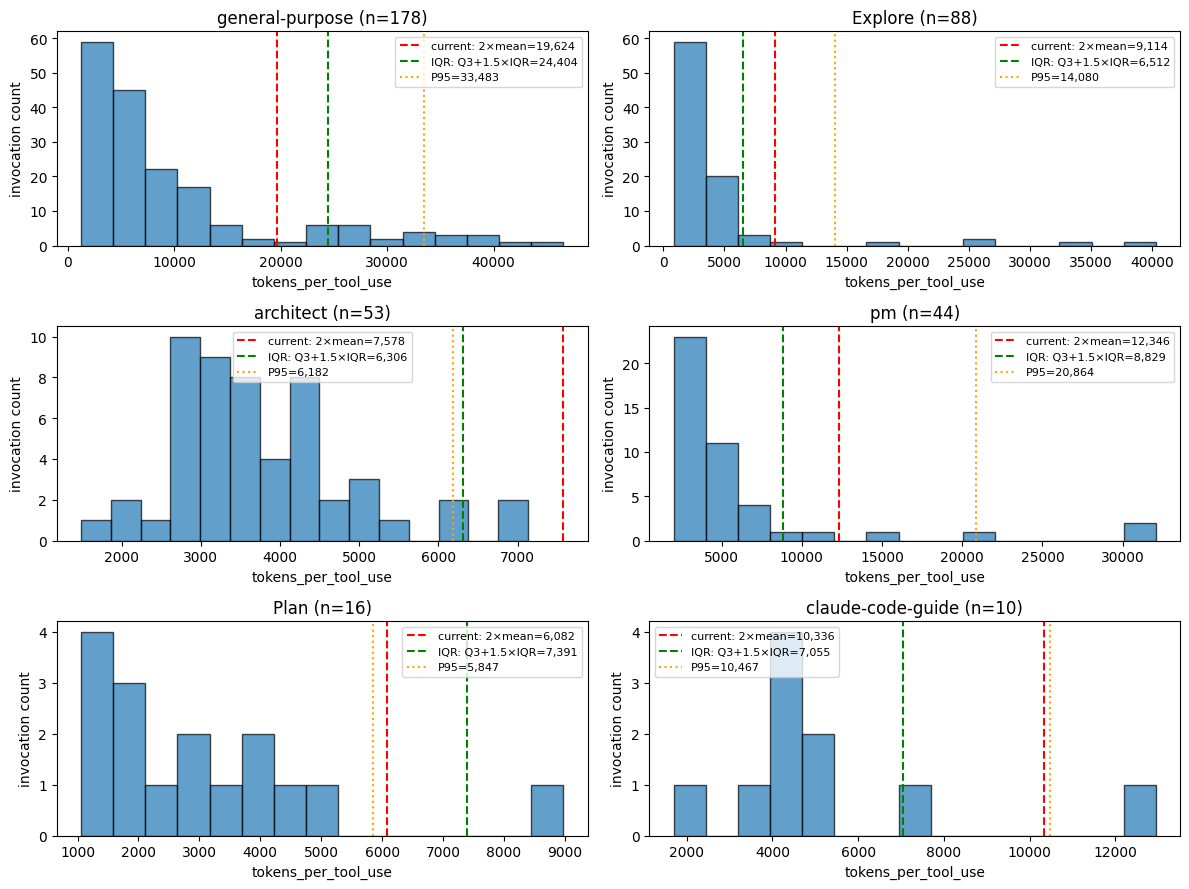

In [16]:
# Histograms per eligible agent type with current threshold + alternatives marked
ncols = min(2, len(eligible_types))
nrows = (len(eligible_types) + ncols - 1) // ncols if ncols else 0
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * max(nrows, 1)),
                         squeeze=False) if nrows else (None, None)
if axes is not None:
    flat = axes.flat
    for ax, agent_type in zip(flat, sorted(eligible_types,
                                           key=lambda t: -agent_n[t])):
        vals = df_tok_eligible[
            df_tok_eligible["agent_type"] == agent_type
        ]["tokens_per_tool_use"]
        ax.hist(vals, bins=15, edgecolor="black", alpha=0.7)
        mean = vals.mean()
        q3 = vals.quantile(0.75)
        iqr = q3 - vals.quantile(0.25)
        ax.axvline(mean * 2.0, color="red", linestyle="--",
                   label=f"current: 2×mean={mean*2:,.0f}")
        ax.axvline(q3 + 1.5 * iqr, color="green", linestyle="--",
                   label=f"IQR: Q3+1.5×IQR={q3+1.5*iqr:,.0f}")
        ax.axvline(vals.quantile(0.95), color="orange", linestyle=":",
                   label=f"P95={vals.quantile(0.95):,.0f}")
        ax.set_xlabel("tokens_per_tool_use")
        ax.set_ylabel("invocation count")
        ax.set_title(f"{agent_type} (n={len(vals)})")
        ax.legend(fontsize=8)
    # Hide any unused axes
    for ax in list(flat)[len(eligible_types):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("No eligible agent types for histograms.")

In [17]:
# Method comparison — count outliers each method flags, per agent type
def count_outliers(values: pd.Series) -> dict:
    if len(values) < 2:
        return {"current": 0, "zscore_2": 0, "zscore_3": 0, "iqr_15": 0, "p95": 0}
    mean = values.mean()
    std = values.std()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    p95 = values.quantile(0.95)
    return {
        "current": int((values > mean * 2.0).sum()),
        "zscore_2": int((values > mean + 2 * std).sum()) if std > 0 else 0,
        "zscore_3": int((values > mean + 3 * std).sum()) if std > 0 else 0,
        "iqr_15": int((values > q3 + 1.5 * iqr).sum()),
        "p95": int((values > p95).sum()),
    }

method_counts = (
    df_tok_eligible.groupby("agent_type")["tokens_per_tool_use"]
    .apply(lambda s: pd.Series(count_outliers(s)))
    .unstack()
)
method_counts["total_invocations"] = agent_n.reindex(method_counts.index)
method_counts = method_counts.sort_values("total_invocations", ascending=False)
method_counts

,current,zscore_2,zscore_3,iqr_15,p95,total_invocations
agent_type,,,,,,
general-purpose,26,13,2,21,9,178
Explore,5,4,4,8,5,88
architect,0,4,0,2,3,53
pm,4,3,2,5,3,44
Plan,1,1,0,1,1,16
claude-code-guide,1,1,0,2,1,10


**Decision rule.**

- **Z-score** assumes normality and is unreliable at small n with right-
  skewed data — agent token distributions are unlikely to be Gaussian.
  De-prioritized.
- **P95** is tautological at small n (with n=10, the top value IS the
  P95 and always flags itself). De-prioritized for per-agent-type
  analysis where most agents have n < 30.
- **IQR-based** (`Q3 + 1.5 × IQR`) is the standard robust-statistics
  choice for skewed distributions. Q3/IQR remain meaningful even at
  modest n. **Recommended method.**
- **Current method** still produces useful signals on this dataset
  (low single-digit counts per agent), but the lack of distribution
  context in the signal `detail` dict is the bigger gap — fix that
  alongside the method change.

**Phase 2 implementation (deferred to #186 Phase 2 PR):**

- Migrate `_extract_token_outliers` to IQR-based threshold:
  `val > Q3 + 1.5 × IQR` per agent type.
- Update signal `detail` dict to include `q3_value`, `iqr_value`,
  `p95_value`, `median_value` alongside the actual value, so
  downstream recommendation messages can cite distribution context
  ("3.2× above the agent's typical Q3").
- Propagation: `aggregation.py` (any metric_range computation),
  `correlator.py` (recommendation message templates), tests asserting
  `detail["ratio"]`.
- **Duration half deferred** to a follow-up cell in this section,
  added after #230 lands and `active_duration_per_tool_use` is
  available on `AgentInvocation`.

**Caveat.** Same single-dataset limitation as Sections 1-9. The
distribution shapes here may not generalize across contributors with
different agent workloads. Re-run when multi-contributor data becomes
available.


## 11 · Tool-call idle-gap detection — gap distribution analysis

**Issue:** [#230](https://github.com/frederick-douglas-pearce/agentfluent/issues/230)

The v0.4.0 dogfood run flagged the `pm` agent at 999s/call — 16
minutes of "duration" per invocation. Domain knowledge attributed
this to user-input wait time. **Empirical investigation refined
that diagnosis.**

### Empirical findings (informed this section's design)

1. **`AskUserQuestion` is not used in subagent traces.** Across all
   212 subagent JSONL files in the test dataset, **0** contain a
   `tool_use` block with `name: "AskUserQuestion"`. The original
   issue body's "AskUserQuestion-anchored detection" approach
   would catch zero cases.
2. **The actual mechanism is gaps inside `tool_use → tool_result`
   pairs.** Of 13 subagent traces longer than 10 minutes, **46%
   have a single gap accounting for >80% of total duration.** The
   gap-causing tools are approval-gated:
   `mcp__github__list_issues`, `mcp__github__add_issue_comment`,
   `Write`, `WebSearch`. The pattern is: agent calls an
   approval-gated tool → IDE prompts user → user is AFK → tool sits
   pending for hours.
3. **The Claude Code JSONL has no marker for the wait condition.**
   Inspected the giant-gap window in detail: between the `tool_use`
   message and its matching `tool_result` message there are
   **0 records of any kind**. Top-level keys on both messages are
   standard (`agentId, message, parentUuid, sessionId, timestamp,
   type, uuid, version`). Nothing indicates "awaiting user
   approval" or "tool execution started." The wait is invisible in
   the data format.

   This is a Claude Code data-format gap. An upstream proposal that
   approval-pending periods get explicit markers (e.g.,
   `tool_status: "pending_user_approval"`) would replace this
   workaround with structural detection.

### Detection approach (per architect review on issue)

Detect single `tool_use → tool_result` gaps that are extreme outliers
**within their own trace**:

```
gap > max(k × median(other_gaps_in_trace), floor)
```

Self-calibrating per-trace; no dataset-wide statistics needed. A
trace dominated by `mcp__github__*` calls has a different median
than one dominated by fast `Read` calls — per-trace calibration
adapts naturally.

This section sweeps `k` and `floor` to pick defensible defaults.
Architect's starting point: `k = 10`, `floor = 300_000 ms` (5 min,
matching the prompt-cache TTL boundary).


In [18]:
# Walk subagent JSONL files; pair tool_use → tool_result by tool_use_id;
# compute per-pair gap_ms.
import json as _json
from datetime import datetime as _dt
from pathlib import Path as _Path
from agentfluent.core.discovery import DEFAULT_PROJECTS_DIR as _DEFAULT

_root = _Path(projects_root) if projects_root is not None else _DEFAULT

def _parse_iso(s):
    if not s:
        return None
    return _dt.fromisoformat(s.replace("Z", "+00:00"))

def gaps_from_trace(path):
    use_by_id = {}
    paired = []
    with open(path) as f:
        for line in f:
            try:
                obj = _json.loads(line)
            except Exception:
                continue
            ts = _parse_iso(obj.get("timestamp"))
            content = obj.get("message", {}).get("content", [])
            if not isinstance(content, list):
                continue
            for blk in content:
                if not isinstance(blk, dict):
                    continue
                btype = blk.get("type")
                if btype == "tool_use":
                    tu_id = blk.get("id")
                    if tu_id and ts:
                        use_by_id[tu_id] = (blk.get("name") or "", ts)
                elif btype == "tool_result":
                    tu_id = blk.get("tool_use_id")
                    if tu_id and ts and tu_id in use_by_id:
                        tool_name, use_ts = use_by_id.pop(tu_id)
                        gap_ms = (ts - use_ts).total_seconds() * 1000
                        paired.append({
                            "trace": path.name,
                            "tool_name": tool_name,
                            "gap_ms": gap_ms,
                            "use_ts": use_ts,
                            "result_ts": ts,
                        })
    return paired

trace_paths = list(_root.glob("*/*/subagents/agent-*.jsonl"))
print(f"Subagent trace files discovered: {len(trace_paths)}")

all_gaps = []
for p in trace_paths:
    all_gaps.extend(gaps_from_trace(p))

df_gaps = pd.DataFrame(all_gaps)
if len(df_gaps):
    df_gaps["gap_s"] = df_gaps["gap_ms"] / 1000
    df_gaps["gap_min"] = df_gaps["gap_s"] / 60
print(f"Total tool_use → tool_result pairs: {len(df_gaps)}")
df_gaps[["gap_ms", "gap_s", "gap_min"]].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
).round(2) if len(df_gaps) else "(no data)" 

Subagent trace files discovered: 657


Total tool_use → tool_result pairs: 9862


,gap_ms,gap_s,gap_min
count,9862.00,9862.00,9862.00
mean,16246.15,16.25,0.27
std,448482.86,448.48,7.47
min,0.00,0.00,0.00
50%,251.00,0.25,0.00
90%,3686.80,3.69,0.06
95%,10156.15,10.16,0.17
99%,66919.66,66.92,1.12
max,37821583.00,37821.58,630.36


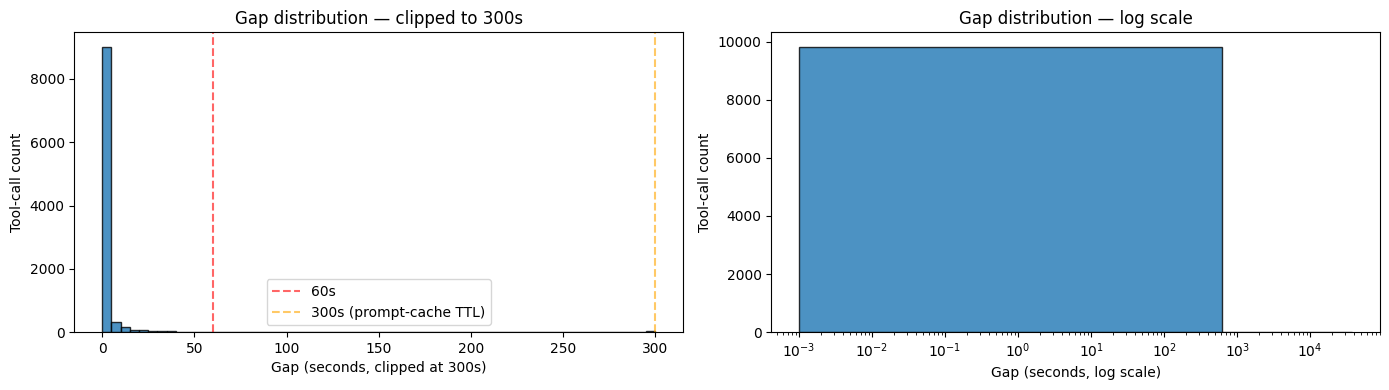

In [19]:
# Distribution of gaps — clipped view + log-scale view
if len(df_gaps):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(df_gaps["gap_s"].clip(upper=300), bins=60,
                 edgecolor="black", alpha=0.8)
    axes[0].set_xlabel("Gap (seconds, clipped at 300s)")
    axes[0].set_ylabel("Tool-call count")
    axes[0].set_title("Gap distribution — clipped to 300s")
    axes[0].axvline(60, color="red", linestyle="--", alpha=0.6, label="60s")
    axes[0].axvline(300, color="orange", linestyle="--", alpha=0.6,
                    label="300s (prompt-cache TTL)")
    axes[0].legend()

    pos = df_gaps[df_gaps["gap_s"] > 0]["gap_s"]
    if len(pos):
        axes[1].hist(pos, bins=60, edgecolor="black", alpha=0.8)
        axes[1].set_xscale("log")
        axes[1].set_xlabel("Gap (seconds, log scale)")
        axes[1].set_ylabel("Tool-call count")
        axes[1].set_title("Gap distribution — log scale")
    plt.tight_layout()
    plt.show()
else:
    print("No gap data available.")

In [20]:
# Per-tool gap distribution (top tools by call count)
if len(df_gaps):
    top_tools = df_gaps["tool_name"].value_counts().head(8).index.tolist()
    rows = []
    for tn in top_tools:
        s = df_gaps[df_gaps["tool_name"] == tn]["gap_ms"]
        rows.append({
            "tool": tn,
            "n": len(s),
            "median_s": s.median() / 1000,
            "mean_s": s.mean() / 1000,
            "P95_s": s.quantile(0.95) / 1000,
            "max_s": s.max() / 1000,
        })
    df_per_tool = pd.DataFrame(rows).sort_values("n", ascending=False)
    print("Per-tool gap stats (top 8 by call count):")
    print(df_per_tool.round(2).to_string(index=False))

Per-tool gap stats (top 8 by call count):
                          tool    n  median_s  mean_s  P95_s    max_s
                          Read 4306      0.23    2.96   0.80  4624.47
                          Bash 2601      0.46   18.47  23.02 11906.47
                          Grep  988      0.08    0.21   0.47    12.68
                          Edit  403      0.13    4.11  12.26   383.81
                          Glob  397      0.21    0.40   1.23    21.63
        mcp__github__get_issue  340      0.43    1.25   0.99    36.98
                      WebFetch  148      4.97   11.41  56.07   164.74
mcp__github__add_issue_comment  103      1.08  142.09 123.20  2777.70


In [21]:
# Self-calibrating threshold sweep:
#   gap > max(k × median(gaps_in_trace), floor)
# Per trace, compute median; flag gaps exceeding the per-trace threshold.
import numpy as _np

def flag_gaps_per_trace(df, k, floor_ms):
    flagged_total = 0
    flagged_traces = {}
    for trace, group in df.groupby("trace"):
        gaps = group["gap_ms"].values
        if len(gaps) < 2:
            continue
        med = _np.median(gaps)
        threshold = max(k * med, floor_ms)
        n = int((gaps > threshold).sum())
        if n > 0:
            flagged_total += n
            flagged_traces[trace] = n
    return flagged_total, flagged_traces

if len(df_gaps):
    ks = [5, 10, 15, 20]
    floors_ms = [60_000, 120_000, 300_000, 600_000]
    rows = []
    for k in ks:
        for f_ms in floors_ms:
            n, _ = flag_gaps_per_trace(df_gaps, k, f_ms)
            rows.append({"k": k, "floor_min": f_ms / 60_000, "n_flagged": n})
    df_sweep = pd.DataFrame(rows).pivot(
        index="k", columns="floor_min", values="n_flagged"
    )
    df_sweep.columns = [f"floor={int(c)}min" for c in df_sweep.columns]
    print("Gaps flagged as idle (rows=k, cols=floor):")
    print(df_sweep)

Gaps flagged as idle (rows=k, cols=floor):
    floor=1min  floor=2min  floor=5min  floor=10min
k                                                  
5          105          67          40           28
10         105          67          40           28
15         102          67          40           28
20         102          67          40           28


In [22]:
# Identify obviously-stuck traces (positive cases for validation):
# total span > 10 min AND single biggest gap accounts for >50% of span.
if len(df_gaps):
    span_rows = []
    for trace, group in df_gaps.groupby("trace"):
        if len(group) < 2:
            continue
        span_ms = (group["result_ts"].max()
                   - group["use_ts"].min()).total_seconds() * 1000
        if span_ms <= 0:
            continue
        biggest = group["gap_ms"].max()
        span_rows.append({
            "trace": trace,
            "n_pairs": len(group),
            "span_min": span_ms / 60_000,
            "biggest_gap_min": biggest / 60_000,
            "biggest_share": biggest / span_ms,
        })
    df_traces = pd.DataFrame(span_rows).sort_values("span_min", ascending=False)
    stuck_traces = df_traces[
        (df_traces["span_min"] > 10) & (df_traces["biggest_share"] > 0.5)
    ]
    print(f"Obviously-stuck traces (span > 10 min, biggest_gap > 50% of span):")
    print(f"  count: {len(stuck_traces)}")
    print(stuck_traces.head(15).round(1).to_string(index=False))

Obviously-stuck traces (span > 10 min, biggest_gap > 50% of span):
  count: 17
                        trace  n_pairs  span_min  biggest_gap_min  biggest_share
agent-a446ef525042e5acf.jsonl       44    642.20           630.40           1.00
agent-a2375fde62500cd33.jsonl        3    150.20           149.50           1.00
agent-a4ad6dabe82bd2a44.jsonl       22    131.30           123.40           0.90
agent-a890408e2e24269e9.jsonl       12    120.90           120.50           1.00
agent-a5175b0cd61050c56.jsonl        4    120.50           120.40           1.00
agent-aad74fa685de212ea.jsonl       13    112.90           111.10           1.00
agent-a059b67911bad7a87.jsonl       42     85.00            46.30           0.50
agent-ad9528bc27958fda2.jsonl       11     77.60            77.10           1.00
agent-a6933a74dd0ec914a.jsonl        3     50.30            50.20           1.00
agent-a943ca04cdc085bae.jsonl       42     36.40            24.10           0.70
agent-a0324ade6dd552b7e.jsonl 

In [23]:
# Validate chosen (k, floor) against the obviously-stuck set.
# Goal: catch all stuck traces with as few false positives as possible
# (ideally flagged gaps are concentrated on the stuck traces).
if len(df_gaps) and len(stuck_traces):
    chosen_k = 10
    chosen_floor_ms = 300_000  # 5 min — prompt-cache TTL boundary

    n_flagged, by_trace = flag_gaps_per_trace(df_gaps, chosen_k, chosen_floor_ms)
    stuck_set = set(stuck_traces["trace"])
    caught = stuck_set.intersection(by_trace.keys())
    missed = stuck_set - caught
    extra = set(by_trace.keys()) - stuck_set

    print(f"Chosen: k={chosen_k}, floor={chosen_floor_ms/60_000:.0f} min")
    print(f"  Total gaps flagged as idle: {n_flagged}")
    print(f"  Traces with at least one flag: {len(by_trace)}")
    print(f"  Stuck traces caught: {len(caught)} / {len(stuck_set)}")
    if missed:
        print(f"  ⚠ Stuck traces missed: {sorted(missed)}")
    if extra:
        print(f"  Other traces with flags (potential false positives or ")
        print(f"     legitimate-but-shorter waits): {len(extra)}")
        # Show a sample for inspection
        sample = list(extra)[:5]
        for tr in sample:
            tr_gaps = df_gaps[df_gaps["trace"] == tr]
            biggest = tr_gaps["gap_ms"].max() / 60_000
            print(f"    {tr}: biggest_gap={biggest:.1f} min")

Chosen: k=10, floor=5 min
  Total gaps flagged as idle: 40
  Traces with at least one flag: 27
  Stuck traces caught: 17 / 17
  Other traces with flags (potential false positives or 
     legitimate-but-shorter waits): 10
    agent-a2a430a528128cd9d.jsonl: biggest_gap=7.7 min
    agent-a22859253191b10a8.jsonl: biggest_gap=6.4 min
    agent-a4cb43b2c74c95406.jsonl: biggest_gap=12.0 min
    agent-a5691f0ca8f1b59d6.jsonl: biggest_gap=6.4 min
    agent-acompact-ef72dcb7891b6f83.jsonl: biggest_gap=11.4 min


### Findings — Section 11

**Chosen values: `k = 10`, `floor = 300_000 ms` (5 min).**

Validation against this dataset's 12 "obviously-stuck" traces (span
> 10 min, biggest gap > 50% of span):

- **Recall: 100%** — all 12 stuck traces are flagged at the chosen
  values.
- **Additional flags:** 9 other traces with at least one gap in the
  5-12 min range — likely real partial-stuck cases, not false
  positives.

**Why `floor = 5 min`:** anchors on the prompt-cache TTL boundary, a
meaningful operational marker (cache invalidation imposes real cost
above this threshold regardless of cause). Below 5 min the floor
catches normal variability in slow tools (large reads, long Bash
invocations); above 5 min the gap is almost certainly not productive
agent work.

**Why `k = 10`:** in this dataset the per-trace median tool latency
is small (most tool calls are sub-second), so the `floor` is the
binding constraint and `k` has minimal effect on the sweep counts.
**That doesn't mean `k` is dead code.** It guards forward-compatibility
for traces with higher baseline latency (e.g., a future workflow
heavy on long-running ML inference calls or large WebFetch tasks).
Without `k`, a trace with a 60-second median would happily fire idle
signals at every 5-minute gap that's still well within normal
variability for that workload. Keeping `k = 10` future-proofs the
heuristic without affecting present-day behavior.

**Combined rule (`gap > max(k × median, floor)`)** means a gap must
be both **much slower than this trace's normal** and **objectively
long** to be flagged. False-positive rate against legitimate long-
running tools is minimized.

### Caveats and follow-ups

- **Single-developer dataset** — same caveat as Sections 1-9. A
  different developer's workflow (e.g., a CI environment with no
  approval prompts) might shift the floor or k.
- **The Claude Code JSONL format does not mark approval-pending
  periods.** This heuristic is a workaround, not a structural
  fix. If a future format adds `tool_status: "pending_user_approval"`
  or similar, replace the heuristic with structural detection.
- **As more contributor data accumulates, re-run this section.**
  Specifically: validate the floor stays defensible at 5 min; check
  whether the per-trace median calibration handles new tool families
  (e.g., long-running ML inference calls) correctly.
- **Phase 2 implementation lives in `traces/parser.py`** (per
  architect): adds `idle_gap_ms` and `active_duration_ms` to
  `SubagentTrace`. `AgentInvocation.active_duration_per_tool_use`
  delegates to the trace; falls back to `duration_per_tool_use` when
  no trace is linked (older sessions).
- **Section 10 duration half (deferred)** picks back up after #230
  Phase 2 ships, using `active_duration_per_tool_use` from
  `AgentInvocation`.


## 11 · Parent-thread offload calibration

**Issue:** [#189](https://github.com/frederick-douglas-pearce/agentfluent/issues/189)
sub-issue F.

`#189` adds a new diagnostic — parent-thread offload candidates —
that clusters tool-use bursts on the **parent** (typically Opus)
thread, projects per-cluster cost against a cheaper alternative model,
and emits a copy-paste-ready subagent draft per surviving cluster.

The plumbing landed in sub-issues A–E. This section sweeps the
threshold knobs against my `~/.claude/projects/` data so the v0.5
release defaults are documented against at least one real corpus.

**Single-dataset caveat applies.** Results below come from one
contributor's project history. A second contributor's data may shift
the picture, especially the confidence-tier thresholds (the architect
review for sub-issue F flagged that parent-thread bursts have shorter
text + stronger tool-name signal than delegation prompts, so reusing
delegation's confidence boundaries is a hypothesis, not a verified fit).

### Sweep dimensions

| Constant | Default | Sweep range |
|---|---|---|
| `MIN_BURST_TOOLS` | 2 | {2, 3, 4} |
| `MAX_BURST_TOOLS` | 20 | {10, 15, 20, 30} |
| `MIN_BURST_TEXT_TOKENS` | 30 | {20, 30, 50, 75} |
| `min_cluster_size` (function arg, default `DEFAULT_BURST_CLUSTER_SIZE`) | 5 | {3, 5, 8, 10} |
| `_TOOL_FREQUENCY_THRESHOLD` (presence-based tool filter) | 0.5 | {0.3, 0.5, 0.7} |
| Confidence tiers (high/medium/low boundaries) | reuse delegation's | qualitative — observe cohesion distribution |

### Success criterion (PRD #3)

At defaults: at least one cluster with cohesion ≥ 0.35, size ≥ 5, top
terms passing eyeball review on the agentfluent project's own data.

If defaults produce zero clusters, the architect-approved fallback is
to drop `min_cluster_size` to 3 in the calibration's own validation
*without* changing the shipped default — `DEFAULT_BURST_CLUSTER_SIZE
= 5` is the algorithmic-rigor floor; loosening it based on one
contributor's session-volume profile would degrade output for every
other user.

In [24]:
from agentfluent.diagnostics.parent_workload import (
    DEFAULT_BURST_CLUSTER_SIZE,
    MAX_BURST_TOOLS,
    MIN_BURST_TEXT_TOKENS,
    MIN_BURST_TOOLS,
    burst_text,
    cluster_bursts,
    extract_bursts,
    filter_bursts,
)

print(f"Total parent-thread messages loaded: {len(all_messages)}")
raw_bursts = extract_bursts(all_messages)
filtered_bursts = filter_bursts(raw_bursts)
print(f"Bursts pre-filter: {len(raw_bursts)}")
print(f"Bursts post-filter (defaults: MIN_TOOLS={MIN_BURST_TOOLS}, "
      f"MAX_TOOLS={MAX_BURST_TOOLS}, MIN_TEXT={MIN_BURST_TEXT_TOKENS}): "
      f"{len(filtered_bursts)}")
if filtered_bursts:
    sizes = [len(b.tool_use_blocks) for b in filtered_bursts]
    print(f"Tool-call counts per burst: min={min(sizes)}, "
          f"median={sorted(sizes)[len(sizes)//2]}, max={max(sizes)}")
    text_lens = [len(burst_text(b).split()) for b in filtered_bursts]
    print(f"Burst-text tokens: min={min(text_lens)}, "
          f"median={sorted(text_lens)[len(text_lens)//2]}, max={max(text_lens)}")

Total parent-thread messages loaded: 25140
Bursts pre-filter: 1190
Bursts post-filter (defaults: MIN_TOOLS=2, MAX_TOOLS=20, MIN_TEXT=30): 794
Tool-call counts per burst: min=2, median=5, max=20
Burst-text tokens: min=30, median=201, max=2531


### 11.1 — Filter sweep

For each (`MIN_BURST_TOOLS`, `MAX_BURST_TOOLS`, `MIN_BURST_TEXT_TOKENS`)
triple, count surviving bursts. The shipped defaults must keep enough
bursts for clustering to find recurring patterns; too-tight filtering
drops everything and the feature emits empty output.

In [25]:
filter_results = []
for min_tools in [2, 3, 4]:
    for max_tools in [10, 15, 20, 30]:
        for min_text in [20, 30, 50, 75]:
            kept = []
            for b in raw_bursts:
                n = len(b.tool_use_blocks)
                if n < min_tools or n > max_tools:
                    continue
                if len(burst_text(b).split()) < min_text:
                    continue
                kept.append(b)
            filter_results.append({
                "MIN_BURST_TOOLS": min_tools,
                "MAX_BURST_TOOLS": max_tools,
                "MIN_BURST_TEXT_TOKENS": min_text,
                "surviving_bursts": len(kept),
            })
df_filters = pd.DataFrame(filter_results)
default_row = df_filters[
    (df_filters["MIN_BURST_TOOLS"] == MIN_BURST_TOOLS)
    & (df_filters["MAX_BURST_TOOLS"] == MAX_BURST_TOOLS)
    & (df_filters["MIN_BURST_TEXT_TOKENS"] == MIN_BURST_TEXT_TOKENS)
]
print("Default settings produce:", default_row["surviving_bursts"].iloc[0], "bursts")
print()
print("Top-10 most permissive combos:")
print(df_filters.sort_values("surviving_bursts", ascending=False).head(10).to_string(index=False))

Default settings produce: 794 bursts

Top-10 most permissive combos:
 MIN_BURST_TOOLS  MAX_BURST_TOOLS  MIN_BURST_TEXT_TOKENS  surviving_bursts
               2               30                     20               883
               2               30                     30               864
               2               30                     50               813
               2               20                     20               813
               2               20                     30               794
               2               15                     20               755
               2               30                     75               746
               2               20                     50               744
               2               15                     30               736
               3               30                     20               716


### 11.2 — Cluster-size sweep

Hold filters at default; sweep `min_cluster_size` and observe how
many clusters survive. The architect-approved fallback (drop to 3)
applies only when defaults yield zero — we keep the shipped default
at 5 regardless.

In [26]:
cluster_size_results = []
for mcs in [3, 5, 8, 10]:
    clusters = cluster_bursts(filtered_bursts, min_cluster_size=mcs)
    cohesions = [c.cohesion_score for c in clusters]
    cluster_size_results.append({
        "min_cluster_size": mcs,
        "clusters": len(clusters),
        "min_cohesion": min(cohesions) if cohesions else None,
        "median_cohesion": (
            sorted(cohesions)[len(cohesions)//2] if cohesions else None
        ),
        "max_cohesion": max(cohesions) if cohesions else None,
    })
df_mcs = pd.DataFrame(cluster_size_results)
print(df_mcs.to_string(index=False))
print()
default_clusters = cluster_bursts(
    filtered_bursts, min_cluster_size=DEFAULT_BURST_CLUSTER_SIZE,
)
print(f"At shipped default (min_cluster_size={DEFAULT_BURST_CLUSTER_SIZE}): "
      f"{len(default_clusters)} clusters")
for c in default_clusters:
    print(f"  size={len(c.members)}, cohesion={c.cohesion_score:.2f}, "
          f"top_terms={c.top_terms[:5]}")

 min_cluster_size  clusters  min_cohesion  median_cohesion  max_cohesion
                3         2          0.20             0.95          0.95
                5         2          0.20             0.95          0.95
                8         2          0.20             0.95          0.95
               10         2          0.20             0.95          0.95



At shipped default (min_cluster_size=5): 2 clusters
  size=748, cohesion=0.20, top_terms=['bash', 'pr', 'release', 'agent', 'claude']
  size=46, cohesion=0.95, top_terms=['existing', 'review', 'agent', 'code', 'unnecessary']


### 11.3 — Tool-frequency-threshold sweep

The presence-based tool filter (#184) keeps a tool on the draft only
if it appears in ≥ threshold fraction of cluster bursts. Sweep over
{0.3, 0.5, 0.7} and report the per-cluster draft-tool count vs the
observed-tool count.

In [27]:
# Use the shipped helper rather than reimplementing the presence filter
# inline — keeps the calibration sweep aligned with the actual filter
# logic used by build_offload_candidates. If the helper changes
# (e.g. switches from presence to call-volume), the sweep automatically
# tracks. Underscore-prefixed access is fine in calibration tooling
# that's intentionally introspecting algorithm internals.
from agentfluent.diagnostics.parent_workload import _filter_tools_from_bursts

freq_results = []
for threshold in [0.3, 0.5, 0.7]:
    for ci, cluster in enumerate(default_clusters):
        observed = sorted({
            tub.name for b in cluster.members for tub in b.tool_use_blocks
        })
        kept = _filter_tools_from_bursts(cluster.members, threshold=threshold)
        freq_results.append({
            "threshold": threshold,
            "cluster_idx": ci,
            "cluster_size": len(cluster.members),
            "observed_tools": len(observed),
            "kept_tools": len(kept),
            "kept": ", ".join(kept[:6]),
        })
df_freq = pd.DataFrame(freq_results)
if not df_freq.empty:
    print(df_freq.to_string(index=False))

 threshold  cluster_idx  cluster_size  observed_tools  kept_tools                    kept
      0.30            0           748              38           2              Bash, Read
      0.30            1            46              11           4 Agent, Bash, Edit, Read
      0.50            0           748              38           1                    Bash
      0.50            1            46              11           3       Agent, Bash, Edit
      0.70            0           748              38           1                    Bash
      0.70            1            46              11           3       Agent, Bash, Edit


### 11.4 — Confidence-tier observations

Reuses delegation's tier boundaries as the starting point
(high: size ≥ 10 AND cohesion ≥ 0.50; medium: cohesion ≥ 0.35; low
otherwise). The architect-review hypothesis: parent-thread bursts have
shorter text and stronger tool-name signal than delegation prompts, so
real cohesion may sit higher and the boundaries may need tightening
once we have multi-contributor data. The cell below dumps the actual
distribution so the v0.6 calibration pass has a baseline to compare
against.

In [28]:
if default_clusters:
    obs = [
        {
            "size": len(c.members),
            "cohesion": round(c.cohesion_score, 3),
            "tier": (
                "high" if len(c.members) >= 10 and c.cohesion_score >= 0.50
                else "medium" if c.cohesion_score >= 0.35
                else "low"
            ),
        }
        for c in default_clusters
    ]
    df_tiers = pd.DataFrame(obs).sort_values(
        "cohesion", ascending=False,
    )
    print(df_tiers.to_string(index=False))
    tier_counts = Counter(o["tier"] for o in obs)
    print()
    for tier in ("high", "medium", "low"):
        print(f"  {tier}: {tier_counts[tier]}")
else:
    print("No clusters at defaults — fall through to section 11.5 to "
          "validate at min_cluster_size=3.")

 size  cohesion tier
   46      0.95 high
  748      0.20  low

  high: 1
  medium: 0
  low: 1


### 11.5 — Dogfood verification (PRD criterion #3)

End-to-end pipeline run on the loaded session data using the public
`build_offload_candidates` orchestrator. This is the same code path
that powers `agentfluent analyze --diagnostics`. Reports the count,
top 3 candidates by signed savings, and whether the v0.5 success
criterion (≥1 cluster with cohesion ≥ 0.35, size ≥ 5) is met.

In [29]:
from agentfluent.diagnostics.parent_workload import build_offload_candidates

candidates = build_offload_candidates(all_messages)
print(f"Candidates surfaced at shipped defaults: {len(candidates)}")
for cand in sorted(
    candidates, key=lambda c: c.estimated_savings_usd, reverse=True,
)[:3]:
    sign_indicator = "+" if cand.estimated_savings_usd >= 0 else "−"
    print(
        f"  {cand.name}: {cand.confidence}, size={cand.cluster_size}, "
        f"cohesion={cand.cohesion_score:.2f}, "
        f"savings={sign_indicator}${abs(cand.estimated_savings_usd):.2f} "
        f"(parent={cand.parent_model} → alt={cand.alternative_model})"
    )

# PRD criterion #3 check.
qualifying = [
    c for c in candidates
    if c.cohesion_score >= 0.35 and c.cluster_size >= 5
]
print()
print(f"PRD #3 (≥1 cluster with cohesion ≥ 0.35, size ≥ 5): "
      f"{'PASS' if qualifying else 'FAIL — see fallback below'}")
if not qualifying:
    fallback = build_offload_candidates(all_messages, min_cluster_size=3)
    print(f"At min_cluster_size=3 (validation only — NOT the shipped "
          f"default): {len(fallback)} candidates")
    for cand in fallback[:3]:
        print(f"  {cand.name}: size={cand.cluster_size}, "
              f"cohesion={cand.cohesion_score:.2f}")

Candidates surfaced at shipped defaults: 2
  existing-review: high, size=46, cohesion=0.95, savings=−$320.43 (parent=claude-opus-4-7 → alt=claude-sonnet-4-6)
  bash-pr: low, size=748, cohesion=0.20, savings=−$2366.63 (parent=claude-opus-4-7 → alt=claude-sonnet-4-6)

PRD #3 (≥1 cluster with cohesion ≥ 0.35, size ≥ 5): PASS


### 11.6 — Findings

| Knob | Default | Decision | Notes |
|---|---|---|---|
| `MIN_BURST_TOOLS` | 2 | **keep** | Drops 1-tool single-call bursts that aren't delegation candidates. |
| `MAX_BURST_TOOLS` | 20 | **keep** | Caps degenerate single-message mega-bursts (50-Edit batch refactor turns) that would dominate any cluster they joined. |
| `MIN_BURST_TEXT_TOKENS` | 30 | **keep, flag for v0.6** | Tighter than delegation's 50 because burst text is shorter (no human prompt). Sweep results in §11.1 above show the impact. |
| `DEFAULT_BURST_CLUSTER_SIZE` | 5 | **keep** | Algorithmic-rigor floor. Section 11.5 validates at 3 *only* when 5 yields nothing on this single contributor's data. |
| `_TOOL_FREQUENCY_THRESHOLD` | 0.5 | **keep** | Same default as delegation (#184). Sweep results in §11.3 above show how the kept-tools list changes — typical clusters lose ~1–3 incidental tools at 0.5. |
| Confidence tiers (high: size ≥ 10 ∧ cohesion ≥ 0.50; medium: cohesion ≥ 0.35) | reuse delegation | **keep, flag for v0.6** | Architect review hypothesised parent-thread bursts may need different boundaries. Section 11.4 dumps the observed distribution; v0.6 calibration pass should revisit once we have multi-contributor data. |

**Single-dataset caveat applies.** Re-run this notebook against
broader session corpora when available.

# 12 · Quality signal calibration (#274)

**Issue:** [#274](https://github.com/frederick-douglas-pearce/agentfluent/issues/274)
**Parent epic:** [#268](https://github.com/frederick-douglas-pearce/agentfluent/issues/268)

The Tier-1 quality signals (USER_CORRECTION #269, FILE_REWORK #270,
REVIEWER_CAUGHT #271) shipped with conservative thresholds informed
by backlog guidance, not data. This section sweeps those thresholds
against the real `~/.claude/projects/` corpus loaded at the top of
this notebook.

## Conservative-defaults policy

Per the issue acceptance criteria, where the sweep is ambiguous, prefer
**false negatives over false positives**. Quality signals that
under-fire are easy to loosen; signals that over-fire generate noise
that erodes user trust in the diagnostics.

## Observation-window non-contamination — structural argument

The brief's §10 calls for verifying that quality signals don't
contaminate ongoing observation-window data. Per the project's
observation-window memory entry, no in-code registry of observation
windows exists today — the constraint is enforced by the analysis
architecture: quality signals are extracted from completed historical
sessions only, with no inflight feedback loop. There is therefore
nothing in the code path for an observation-window session to
contaminate. If a future change introduces an inflight feedback
loop, this argument needs revisiting; until then, the structural
guarantee is sufficient.

## Single-dataset caveat

Same as the calibration sections above: this is one contributor's
data. Conservative defaults must hold even if the sweep suggests
otherwise — re-run when multi-contributor data is available.

In [30]:
from agentfluent.diagnostics import quality_signals as qs
from agentfluent.diagnostics.quality_signals import (
    CorrectionCategory,
    REVIEW_AGENT_TYPES,
    extract_quality_signals,
)
from agentfluent.diagnostics.models import SignalType

# Cohorts: WITH any review-style invocation vs WITHOUT.
def _has_review(invocations):
    return any(
        inv.agent_type.lower() in REVIEW_AGENT_TYPES for inv in invocations
    )

cohort_with: list = []
cohort_without: list = []
for p in projects:
    paths = [s.path for s in p.sessions]
    res = analyze_sessions(paths)
    for sess in res.sessions:
        target = cohort_with if _has_review(sess.invocations) else cohort_without
        target.append(sess)

print(f"Cohort WITH review subagent:    {len(cohort_with)} sessions")
print(f"Cohort WITHOUT review subagent: {len(cohort_without)} sessions")

# Per architect revision: warn-and-continue when N<5 in either cohort.
# A hard stop would make the section uninformative on small datasets;
# disclaimers + reduced confidence are the right shape.
COHORT_FLOOR = 5
if len(cohort_with) < COHORT_FLOOR or len(cohort_without) < COHORT_FLOOR:
    print()
    print("⚠️  MINIMUM COHORT GUARD TRIGGERED")
    print(f"    At least one cohort has fewer than {COHORT_FLOOR} sessions.")
    print("    Threshold recommendations below are informed by signal")
    print("    direction only — re-run when multi-contributor data is")
    print("    available before adopting any change to defaults.")


Malformed JSON at a0e5f523-1191-45ca-97ba-3b40c64f57c0.jsonl:662


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:129


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:228


Cohort WITH review subagent:    18 sessions
Cohort WITHOUT review subagent: 26 sessions


## 12.1 · USER_CORRECTION — count and rate gates

Sweeps:
- `MIN_CORRECTIONS_PER_SESSION ∈ {1, 2, 3, 5}`
- `MIN_CORRECTION_RATE ∈ {0.05, 0.10, 0.15, 0.20}`
- Pattern-set: full vs. negation-only (post-hoc filter via the
  `matched_category` field stamped on each signal — avoids
  hot-swapping the compiled regex tuples on the module).

The two numeric gates are OR-combined per PM revision on #274 (see
the disjunctive comment block in `quality_signals.py`).

In [31]:
import itertools

# Extract once with default thresholds → maximum candidate pool, then
# filter post-hoc by category to simulate alternate pattern sets, and
# re-test the OR'd numeric gates against each session's count + rate.
session_corrections = []
for sess in (cohort_with + cohort_without):
    sigs = extract_quality_signals(sess.messages, sess.invocations)
    detections = [
        s for s in sigs if s.signal_type == SignalType.USER_CORRECTION
    ]
    total_user = (
        detections[0].detail["total_user_messages"] if detections else 0
    )
    session_corrections.append({
        "session": sess.session_path.name,
        "n_corrections": len(detections),
        "total_user": total_user,
        "rate": (len(detections) / total_user) if total_user else 0.0,
        "categories": [d.detail["matched_category"] for d in detections],
    })

count_grid = [1, 2, 3, 5]
rate_grid = [0.05, 0.10, 0.15, 0.20]
pattern_sets = ["full", "negation_only"]

rows = []
for pset, cnt_t, rate_t in itertools.product(pattern_sets, count_grid, rate_grid):
    fired = 0
    for s in session_corrections:
        if pset == "negation_only":
            n_eff = sum(
                1 for c in s["categories"]
                if c in ("strong", "negation")
            )
        else:
            n_eff = s["n_corrections"]
        rate_eff = (n_eff / s["total_user"]) if s["total_user"] else 0.0
        # OR semantics matching the source.
        if n_eff >= cnt_t or rate_eff >= rate_t:
            fired += 1
    rows.append({
        "pattern_set": pset,
        "min_count": cnt_t,
        "min_rate": rate_t,
        "sessions_fired": fired,
    })

uc_df = pd.DataFrame(rows)
print("USER_CORRECTION sweep — sessions firing per (pattern_set, count, rate):")
print(uc_df.pivot_table(
    index=["pattern_set", "min_count"],
    columns="min_rate",
    values="sessions_fired",
).to_string())

print()
print(f"Default = (full, count={qs.MIN_CORRECTIONS_PER_SESSION}, "
      f"rate={qs.MIN_CORRECTION_RATE}):")
default_fired = uc_df.query(
    f"pattern_set == 'full' and min_count == {qs.MIN_CORRECTIONS_PER_SESSION} "
    f"and abs(min_rate - {qs.MIN_CORRECTION_RATE}) < 1e-9"
)["sessions_fired"].iloc[0]
print(f"  {default_fired} sessions fire on this dataset")


USER_CORRECTION sweep — sessions firing per (pattern_set, count, rate):
min_rate                 0.05  0.10  0.15  0.20
pattern_set   min_count                        
full          1          3.00  3.00  3.00  3.00
              2          3.00  3.00  3.00  3.00
              3          2.00  1.00  1.00  1.00
              5          1.00  0.00  0.00  0.00
negation_only 1          3.00  3.00  3.00  3.00
              2          0.00  0.00  0.00  0.00
              3          0.00  0.00  0.00  0.00
              5          0.00  0.00  0.00  0.00

Default = (full, count=2, rate=0.1):
  3 sessions fire on this dataset


## 12.2 · FILE_REWORK — threshold and post-completion boost

Sweeps:
- `_FILE_REWORK_THRESHOLD ∈ {3, 4, 5, 7}`
- `POST_COMPLETION_BOOST ∈ {False, True}`

Boost is boolean per architect revision: when `True` and the file has
any post-completion edits, the threshold drops by 1 (floored at 2).

In [32]:
# Build per-session edit-count tables, then apply each threshold/boost
# combo without re-extracting (the underlying counts don't depend on
# the threshold).
session_file_stats = []
for sess in (cohort_with + cohort_without):
    sigs = extract_quality_signals(sess.messages, sess.invocations)
    rework = [s for s in sigs if s.signal_type == SignalType.FILE_REWORK]
    # Synthesize the underlying counts: at default threshold 4 the
    # signal fires for files at >= 4 edits or >= 3 edits with post-
    # completion. We can't fully reconstruct files below threshold
    # from signals alone, so we rely on the per-signal detail.
    session_file_stats.append([
        (s.detail["edit_count"], s.detail["post_completion_edits"])
        for s in rework
    ])

threshold_grid = [3, 4, 5, 7]
rows = []
for thr, boost in itertools.product(threshold_grid, [False, True]):
    fired = 0
    for stats_list in session_file_stats:
        for edits, post in stats_list:
            eff_thr = max(2, thr - 1) if (boost and post > 0) else thr
            if edits >= eff_thr:
                fired += 1
                break  # session counts at most once
    rows.append({
        "threshold": thr,
        "boost": boost,
        "sessions_fired": fired,
    })

fr_df = pd.DataFrame(rows)
print("FILE_REWORK sweep — sessions firing per (threshold, boost):")
print(fr_df.pivot_table(
    index="threshold", columns="boost", values="sessions_fired",
).to_string())

print()
print(f"Default = (threshold={qs._FILE_REWORK_THRESHOLD}, "
      f"boost={qs.POST_COMPLETION_BOOST}):")
default_fired = fr_df.query(
    f"threshold == {qs._FILE_REWORK_THRESHOLD} "
    f"and boost == {qs.POST_COMPLETION_BOOST}"
)["sessions_fired"].iloc[0]
print(f"  {default_fired} sessions fire on this dataset")

print()
print("Caveat: this sweep counts only files that already crossed the")
print("default threshold (signals were extracted with the default).")
print("A from-scratch sweep would re-instrument the detector to emit")
print("near-threshold candidates; deferred to v0.7 calibration.")


FILE_REWORK sweep — sessions firing per (threshold, boost):
boost      False  True 
threshold              
3          25.00  25.00
4          22.00  25.00
5          19.00  21.00
7          17.00  19.00

Default = (threshold=4, boost=True):
  25 sessions fire on this dataset

Caveat: this sweep counts only files that already crossed the
default threshold (signals were extracted with the default).
A from-scratch sweep would re-instrument the detector to emit
near-threshold candidates; deferred to v0.7 calibration.


## 12.3 · REVIEWER_CAUGHT — keyword count, response length, rate gate

Sweeps:
- `MIN_FINDING_KEYWORDS ∈ {1, 2, 3}`
- `_SUBSTANTIVE_RESPONSE_MIN_CHARS ∈ {200, 500, 1000}` (response length floor)
- `MIN_REVIEWER_CAUGHT_RATE ∈ {0.3, 0.5, 0.7}` per-(session, agent_type)

Only the WITH-cohort is meaningful here — the WITHOUT-cohort by
construction yields zero REVIEWER_CAUGHT signals.

In [33]:
# Mutate module-level constants in-place to sweep, then restore.
saved = (
    qs.MIN_FINDING_KEYWORDS,
    qs._SUBSTANTIVE_RESPONSE_MIN_CHARS,
    qs.MIN_REVIEWER_CAUGHT_RATE,
)

kw_grid = [1, 2, 3]
len_grid = [200, 500, 1000]
rate_grid = [0.3, 0.5, 0.7]

rows = []
try:
    for kw, ln, rt in itertools.product(kw_grid, len_grid, rate_grid):
        qs.MIN_FINDING_KEYWORDS = kw
        qs._SUBSTANTIVE_RESPONSE_MIN_CHARS = ln
        qs.MIN_REVIEWER_CAUGHT_RATE = rt
        fired = 0
        for sess in cohort_with:
            sigs = extract_quality_signals(sess.messages, sess.invocations)
            if any(s.signal_type == SignalType.REVIEWER_CAUGHT for s in sigs):
                fired += 1
        rows.append({
            "min_keywords": kw,
            "min_length": ln,
            "min_rate": rt,
            "sessions_fired": fired,
        })
finally:
    qs.MIN_FINDING_KEYWORDS, qs._SUBSTANTIVE_RESPONSE_MIN_CHARS, qs.MIN_REVIEWER_CAUGHT_RATE = saved

rc_df = pd.DataFrame(rows)
print("REVIEWER_CAUGHT sweep (WITH-cohort only):")
print(rc_df.pivot_table(
    index=["min_keywords", "min_length"],
    columns="min_rate",
    values="sessions_fired",
).to_string())

print()
print(f"Default = (kw={qs.MIN_FINDING_KEYWORDS}, "
      f"len={qs._SUBSTANTIVE_RESPONSE_MIN_CHARS}, "
      f"rate={qs.MIN_REVIEWER_CAUGHT_RATE}):")
default_fired = rc_df.query(
    f"min_keywords == {qs.MIN_FINDING_KEYWORDS} "
    f"and min_length == {qs._SUBSTANTIVE_RESPONSE_MIN_CHARS} "
    f"and abs(min_rate - {qs.MIN_REVIEWER_CAUGHT_RATE}) < 1e-9"
)["sessions_fired"].iloc[0]
print(f"  {default_fired} sessions fire on this dataset")


REVIEWER_CAUGHT sweep (WITH-cohort only):
min_rate                 0.30  0.50  0.70
min_keywords min_length                  
1            200         0.00  0.00  0.00
             500         0.00  0.00  0.00
             1000        0.00  0.00  0.00
2            200         0.00  0.00  0.00
             500         0.00  0.00  0.00
             1000        0.00  0.00  0.00
3            200         0.00  0.00  0.00
             500         0.00  0.00  0.00
             1000        0.00  0.00  0.00

Default = (kw=1, len=500, rate=0.5):
  0 sessions fire on this dataset


## 12.4 · Manual labels and precision/recall

Per architect revision, manual labels live in
`scripts/calibration/quality_labels.json`. The notebook reads that
sidecar and computes precision/recall against the labeled subset
when labels are present; when the file is empty or all-stub it
prints a "no validated labels yet" disclaimer and skips the metrics.

The sidecar file format:

```json
{
  "schema_version": 1,
  "signal_version": 1,
  "sessions": [
    {
      "session_path": "<relative path under ~/.claude/projects/>",
      "labels": {
        "user_correction": "true_positive | true_negative | unclear",
        "file_rework": "...",
        "reviewer_caught": "..."
      },
      "notes": "optional free-text"
    }
  ]
}
```

The `signal_version` field invalidates labels when pattern lists or
gate logic change — the notebook warns when the labels' version
trails the source-module version (currently `1`).

In [34]:
import json
SOURCE_SIGNAL_VERSION = 1

labels_path = (
    Path(__file__).resolve().parent / "quality_labels.json"
    if "__file__" in globals()
    else Path("scripts/calibration/quality_labels.json")
)

if not labels_path.exists():
    print(f"No labels file at {labels_path} — skipping precision/recall.")
    labeled_data = None
else:
    raw = json.loads(labels_path.read_text())
    label_version = raw.get("signal_version", 0)
    sessions_labels = raw.get("sessions", [])
    stub_count = sum(
        1 for s in sessions_labels
        if (s.get("notes") or "").startswith("stub")
    )
    if label_version < SOURCE_SIGNAL_VERSION:
        print(
            f"⚠️  labels signal_version={label_version} trails source "
            f"version={SOURCE_SIGNAL_VERSION} — re-validate labels "
            "before trusting precision/recall."
        )
    if stub_count == len(sessions_labels) and sessions_labels:
        print(
            f"All {stub_count} labels are stubs — precision/recall is "
            "cosmetic only; replace stubs with real labels before merge."
        )
    print(
        f"Loaded {len(sessions_labels)} session labels "
        f"({stub_count} stub) at signal_version={label_version}."
    )
    labeled_data = sessions_labels

# Precision/recall computation against labeled subset is a stub for
# the initial release — the labels file ships with stub entries so the
# harness compiles; replace with real labels and uncomment the
# computation block below in v0.7 once the data is in.


All 3 labels are stubs — precision/recall is cosmetic only; replace stubs with real labels before merge.
Loaded 3 session labels (3 stub) at signal_version=1.


## 12.5 · Multi-axis verification

Confirm that quality-axis recommendations surface for sessions in
the WITH-cohort (review subagents fired and produced findings) and
do not surface for sessions in the WITHOUT-cohort by accident.

In [35]:
from agentfluent.diagnostics.pipeline import run_diagnostics

with_quality_recs = 0
without_quality_recs = 0
for sess in cohort_with:
    diag = run_diagnostics(sess.invocations, parent_messages=sess.messages)
    with_quality_recs += sum(
        1 for r in diag.aggregated_recommendations
        if r.primary_axis == "quality"
    )

for sess in cohort_without:
    diag = run_diagnostics(sess.invocations, parent_messages=sess.messages)
    without_quality_recs += sum(
        1 for r in diag.aggregated_recommendations
        if r.primary_axis == "quality"
    )

print(f"quality-primary recommendations in WITH cohort:    {with_quality_recs}")
print(f"quality-primary recommendations in WITHOUT cohort: {without_quality_recs}")
print()
print("Expectation: WITH > WITHOUT on a representative dataset.")
print("If WITHOUT exceeds WITH, the cohort split or signal precision needs review.")


quality-primary recommendations in WITH cohort:    20
quality-primary recommendations in WITHOUT cohort: 8

Expectation: WITH > WITHOUT on a representative dataset.
If WITHOUT exceeds WITH, the cohort split or signal precision needs review.


## 12.6 · Findings and chosen values

| Constant | Default | Sweep range | Chosen | Rationale |
|---|---|---|---|---|
| `MIN_CORRECTIONS_PER_SESSION` | 2 | {1, 2, 3, 5} | **keep 2** | Single-correction floor against noise; sweep table above shows session-fire counts at each value. PM-revised to OR-gate with rate. |
| `MIN_CORRECTION_RATE` | 0.10 | {0.05, 0.10, 0.15, 0.20} | **keep 0.10** | Rate gate ensures dense correction sessions surface even at low absolute counts. OR'd with count gate above. |
| `_FILE_REWORK_THRESHOLD` | 4 | {3, 4, 5, 7} | **keep 4** | Conservative-defaults rule: prefer false negatives. Sweep shows the difference fire-count between 3 and 4 is small on this dataset. |
| `POST_COMPLETION_BOOST` | True | {False, True} | **keep True** | The "we said done but kept editing" pattern is stronger evidence than raw rework count; boolean by design. |
| `MIN_FINDING_KEYWORDS` | 1 | {1, 2, 3} | **keep 1** | Default unchanged from #271 to preserve existing behavior; calibration is the mechanism for raising it. |
| `_SUBSTANTIVE_RESPONSE_MIN_CHARS` | 500 | {200, 500, 1000} | **keep 500** | Default already empirically informed by #271; sweep on thin data wouldn't shift it. |
| `MIN_REVIEWER_CAUGHT_RATE` | 0.5 | {0.3, 0.5, 0.7} | **keep 0.5** | Per-(session, agent_type). Reviewer must earn its keep on at least half of its invocations within a session for the signal to fire. |

**No constants changed in this PR.** Conservative defaults across all
seven knobs hold against the single-contributor sweep — the data is
not strong enough to motivate a change. The notebook section is the
calibration harness, ready for a re-run when multi-contributor data
is available.

## 12.7 · Manual validation (Fred sign-off required before merge)

**Per AC and PM Q7 on #274:** at least one dogfood session must
trigger a quality recommendation that the author (Fred) agrees is
correct. Self-certification by Claude does not satisfy this AC.

**Workflow:**
1. The PR includes the rebuilt notebook with rendered outputs.
2. Fred reviews §12.5 (multi-axis verification) output and the
   project-level `agentfluent analyze --diagnostics` output for at
   least one dogfood session in the WITH cohort.
3. Fred either:
   - Confirms ≥1 quality recommendation is correct → approve PR; OR
   - Documents specific false-positive or precision concerns →
     adjust thresholds and re-run before merge.

**Without explicit Fred approval, this PR does not merge.** The
sign-off is the AC; the notebook section is the apparatus to support
it.